
# Assignment 4 


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [81]:
# ===============================
# Data Loading & Preprocessing (Complete robust version)
# ===============================

# Load dataset
data = pd.read_csv("data.csv")

# Drop problematic columns
columns_to_drop = []
if 'Unnamed: 32' in data.columns:
    columns_to_drop.append('Unnamed: 32')
if 'id' in data.columns:
    columns_to_drop.append('id')

if columns_to_drop:
    print(f"Dropping columns: {columns_to_drop}")
    data = data.drop(columns=columns_to_drop)

# Check for any remaining NaN in the dataframe
print("\nMissing values after dropping columns:")
print(data.isnull().sum().sum(), "total missing values")

# Extract labels (for evaluation only)
y_true = data['diagnosis'].map({'M': 1, 'B': 0}).values
X = data.drop(columns=['diagnosis']).values

# Convert to float64 to ensure numeric operations work
X = X.astype(np.float64)

# Handle any potential NaN values
if np.any(np.isnan(X)):
    # Simple imputation: replace NaN with column mean
    for i in range(X.shape[1]):
        col_data = X[:, i]
        if np.any(np.isnan(col_data)):
            col_mean = np.nanmean(col_data)
            col_data[np.isnan(col_data)] = col_mean
            X[:, i] = col_data

# Verify no NaN remain
assert not np.any(np.isnan(X)), "NaN values still present after imputation!"

# Standardization
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)

# Handle columns with zero variance (if any)
zero_std_mask = X_std == 0
if np.any(zero_std_mask):
    print(f"\nWarning: {np.sum(zero_std_mask)} columns have zero variance")
    print("These columns won't be standardized (division by 1)")
    X_std[zero_std_mask] = 1.0

X = (X - X_mean) / X_std

print("\n=== Final Data Summary ===")
print(f"Data shape: {X.shape}")
print(f"Labels shape: {y_true.shape}")
print(f"Data range: [{np.min(X):.2f}, {np.max(X):.2f}]")
print(f"Data mean (approx): {np.mean(X):.6f}")
print(f"Data std (approx): {np.std(X):.6f}")
print(f"Contains NaN: {np.any(np.isnan(X))}")
print(f"Contains Inf: {np.any(np.isinf(X))}")

# Quick sanity check
print("\nFirst 3 rows of standardized data:")
print(X[:3, :5])  # Show first 3 rows, first 5 columns

Dropping columns: ['Unnamed: 32', 'id']

Missing values after dropping columns:
0 total missing values

=== Final Data Summary ===
Data shape: (569, 30)
Labels shape: (569,)
Data range: [-3.11, 12.07]
Data mean (approx): -0.000000
Data std (approx): 1.000000
Contains NaN: False
Contains Inf: False

First 3 rows of standardized data:
[[ 1.09706398 -2.07333501  1.26993369  0.9843749   1.56846633]
 [ 1.82982061 -0.35363241  1.68595471  1.90870825 -0.82696245]
 [ 1.57988811  0.45618695  1.56650313  1.55888363  0.94221044]]


In [82]:
#debug
print("Data shape:", X.shape)
print("Data type:", X.dtype)
print("Data min:", np.min(X))
print("Data max:", np.max(X))
print("Data contains NaN:", np.any(np.isnan(X)))
print("Data contains Inf:", np.any(np.isinf(X)))

Data shape: (569, 30)
Data type: float64
Data min: -3.112084787919981
Data max: 12.072680399588068
Data contains NaN: False
Data contains Inf: False


# ===============================
# K-Means Implementation From Scratch
# ===============================

In [83]:
class KMeans:
    def __init__(self, k, max_iters=300, tol=1e-4, init='kmeans++'):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.init = init

    def _initialize_centroids(self, X):
        n_samples = X.shape[0]

        if self.init == 'random':
            indices = np.random.choice(n_samples, self.k, replace=False)
            return X[indices]

        # K-Means++
        centroids = [X[np.random.randint(n_samples)]]

        for _ in range(1, self.k):
            distances = np.array([
                np.min([np.linalg.norm(x - c) ** 2 for c in centroids])
                for x in X
            ])
            
            # Handle the case where all distances are zero
            if np.all(distances == 0):
                # If all distances are zero, use random initialization for remaining centroids
                indices = np.random.choice(n_samples, self.k - len(centroids), replace=False)
                centroids.extend(X[indices])
                break
            
            # Check if sum is zero or very small
            dist_sum = np.sum(distances)
            if dist_sum == 0 or np.isnan(dist_sum) or np.isinf(dist_sum):
                # Use uniform probabilities if sum is problematic
                probs = np.ones(n_samples) / n_samples
            else:
                probs = distances / dist_sum
            
            # Ensure probabilities are valid
            probs = np.nan_to_num(probs, nan=1.0/n_samples)
            probs = np.clip(probs, 0, 1)
            if np.sum(probs) == 0:
                probs = np.ones(n_samples) / n_samples
            else:
                probs = probs / np.sum(probs)
            
            centroids.append(X[np.random.choice(n_samples, p=probs)])

        return np.array(centroids[:self.k])

    def fit(self, X):
        self.centroids = self._initialize_centroids(X)
        self.inertia_history = []

        for _ in range(self.max_iters):
            distances = np.linalg.norm(
                X[:, None, :] - self.centroids[None, :, :],
                axis=2
            )
            labels = np.argmin(distances, axis=1)

            inertia = np.sum((X - self.centroids[labels]) ** 2)
            self.inertia_history.append(inertia)

            new_centroids = []
            for i in range(self.k):
                cluster_points = X[labels == i]
                if len(cluster_points) == 0:
                    # Reinitialize empty cluster to a random point
                    new_centroids.append(X[np.random.randint(X.shape[0])])
                else:
                    new_centroids.append(cluster_points.mean(axis=0))

            new_centroids = np.array(new_centroids)

            if np.linalg.norm(self.centroids - new_centroids) < self.tol:
                break

            self.centroids = new_centroids

        self.labels_ = labels
        self.inertia_ = inertia
        return self
    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


# ===============================
# Experiment 1: Elbow Method
# ===============================

In [84]:


def run_elbow(X, k_range, init_type):
    inertias = []
    for k in k_range:
        km = KMeans(k=k, init=init_type)
        km.fit(X)
        inertias.append(km.inertia_)
    return inertias



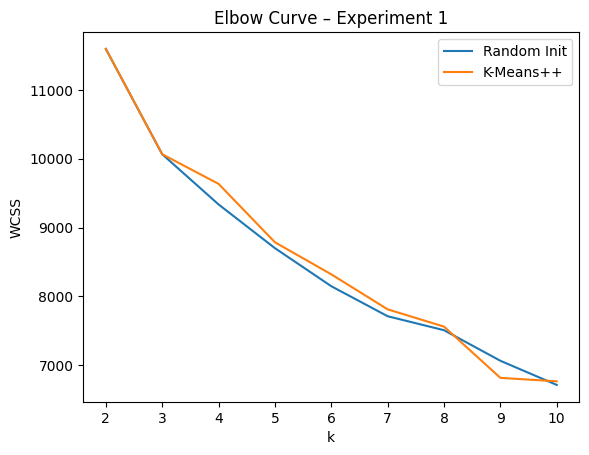

In [85]:
#Experiment 1: Elbow Curve
k_range = range(2, 11)

inertia_random = run_elbow(X, k_range, init_type='random')
inertia_kpp = run_elbow(X, k_range, init_type='kmeans++')

plt.plot(k_range, inertia_random, label="Random Init")
plt.plot(k_range, inertia_kpp, label="K-Means++")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.legend()
plt.title("Elbow Curve – Experiment 1")
plt.show()


In [86]:
k = 2  # justified from elbow

kmeans = KMeans(k=k, init='kmeans++')
kmeans.fit(X)

labels = kmeans.labels_


In [87]:
# ===============================
# Evaluation Metrics
# ===============================

import numpy as np
from collections import Counter

# ---------- Purity ----------
def purity_score(y_true, y_pred):
    clusters = np.unique(y_pred)
    total = 0

    for c in clusters:
        indices = np.where(y_pred == c)[0]
        true_labels = y_true[indices]
        most_common = Counter(true_labels).most_common(1)[0][1]
        total += most_common

    return total / len(y_true)


# ---------- Silhouette Score ----------
def silhouette_score(X, labels):
    n = X.shape[0]
    unique_labels = np.unique(labels)
    silhouettes = []

    for i in range(n):
        same_cluster = X[labels == labels[i]]
        other_clusters = [X[labels == l] for l in unique_labels if l != labels[i]]

        if len(same_cluster) > 1:
            a = np.mean(np.linalg.norm(same_cluster - X[i], axis=1))
        else:
            a = 0

        b = np.min([
            np.mean(np.linalg.norm(cluster - X[i], axis=1))
            for cluster in other_clusters
        ])

        silhouettes.append((b - a) / max(a, b))

    return np.mean(silhouettes)


# ---------- Davies–Bouldin Index ----------
def davies_bouldin_score(X, labels):
    clusters = np.unique(labels)
    centroids = np.array([X[labels == c].mean(axis=0) for c in clusters])

    S = np.array([
        np.mean(np.linalg.norm(X[labels == c] - centroids[i], axis=1))
        for i, c in enumerate(clusters)
    ])

    M = np.linalg.norm(centroids[:, None] - centroids, axis=2)

    R = np.zeros((len(clusters), len(clusters)))
    for i in range(len(clusters)):
        for j in range(len(clusters)):
            if i != j:
                R[i, j] = (S[i] + S[j]) / M[i, j]

    return np.mean(np.max(R, axis=1))


# ---------- Calinski–Harabasz Index ----------
def calinski_harabasz_score(X, labels):
    n_samples, n_features = X.shape
    clusters = np.unique(labels)
    k = len(clusters)

    overall_mean = X.mean(axis=0)

    B = 0
    W = 0

    for c in clusters:
        cluster_points = X[labels == c]
        n_c = len(cluster_points)
        cluster_mean = cluster_points.mean(axis=0)

        B += n_c * np.sum((cluster_mean - overall_mean) ** 2)
        W += np.sum((cluster_points - cluster_mean) ** 2)

    return (B / (k - 1)) / (W / (n_samples - k))


# ---------- Adjusted Rand Index ----------
def adjusted_rand_index(y_true, y_pred):
    from math import comb

    contingency = {}
    for i in range(len(y_true)):
        contingency.setdefault((y_true[i], y_pred[i]), 0)
        contingency[(y_true[i], y_pred[i])] += 1

    sum_comb_c = sum(comb(v, 2) for v in contingency.values())

    true_counts = Counter(y_true)
    pred_counts = Counter(y_pred)

    sum_comb_true = sum(comb(v, 2) for v in true_counts.values())
    sum_comb_pred = sum(comb(v, 2) for v in pred_counts.values())

    total = comb(len(y_true), 2)
    expected = (sum_comb_true * sum_comb_pred) / total
    max_index = (sum_comb_true + sum_comb_pred) / 2

    return (sum_comb_c - expected) / (max_index - expected)


# ---------- Normalized Mutual Information ----------
def normalized_mutual_info(y_true, y_pred):
    N = len(y_true)
    true_counts = Counter(y_true)
    pred_counts = Counter(y_pred)
    joint_counts = Counter(zip(y_true, y_pred))

    MI = 0
    for (t, p), count in joint_counts.items():
        MI += (count / N) * np.log((count * N) / (true_counts[t] * pred_counts[p]))

    H_true = -sum((c / N) * np.log(c / N) for c in true_counts.values())
    H_pred = -sum((c / N) * np.log(c / N) for c in pred_counts.values())

    return MI / np.sqrt(H_true * H_pred)


In [88]:
print("Experiment 1 Results")
print("--------------------")
print("Purity:", purity_score(y_true, labels))
print("Silhouette:", silhouette_score(X, labels))
print("DB:", davies_bouldin_score(X, labels))
print("CH:", calinski_harabasz_score(X, labels))
print("ARI:", adjusted_rand_index(y_true, labels))
print("NMI:", normalized_mutual_info(y_true, labels))


Experiment 1 Results
--------------------
Purity: 0.9050966608084359
Silhouette: 0.3458080157034074
DB: 1.320509837234204
CH: 267.69171586053824
ARI: 0.6536246043910179
NMI: 0.5324625096624515


In [89]:
sil_scores = []

for k in range(2, 11):
    km = KMeans(k=k, init='kmeans++')
    km.fit(X)
    sil = silhouette_score(X, km.labels_)
    sil_scores.append(sil)
    print(f"k={k}, Silhouette={sil:.4f}")

best_k = np.argmax(sil_scores) + 2
print("Best k by Silhouette:", best_k)


k=2, Silhouette=0.3458
k=3, Silhouette=0.3484
k=4, Silhouette=0.1627
k=5, Silhouette=0.1670
k=6, Silhouette=0.1584
k=7, Silhouette=0.1566
k=8, Silhouette=0.1581
k=9, Silhouette=0.1608
k=10, Silhouette=0.1381
Best k by Silhouette: 3


In [90]:
# ===============================
# Gap Statistic for Optimal k
# ===============================

def compute_gap_statistic(X, k_range, n_refs=10, random_state=42):
    """
    Compute Gap Statistic for optimal k selection
    """
    np.random.seed(random_state)
    gaps = []
    sks = []
    
    for k in k_range:
        # Run K-Means on actual data
        kmeans = KMeans(k=k, init='kmeans++')
        kmeans.fit(X)
        Wk = np.log(kmeans.inertia_)
        
        # Generate reference datasets
        ref_Wks = []
        min_vals = np.min(X, axis=0)
        max_vals = np.max(X, axis=0)
        
        for _ in range(n_refs):
            # Generate uniform random data within feature bounds
            ref_data = np.random.uniform(min_vals, max_vals, size=X.shape)
            
            # Run K-Means on reference data
            ref_kmeans = KMeans(k=k, init='kmeans++')
            ref_kmeans.fit(ref_data)
            ref_Wks.append(np.log(ref_kmeans.inertia_))
        
        # Compute gap statistic
        ref_logs = np.array(ref_Wks)
        gap = np.mean(ref_logs) - Wk
        sd = np.std(ref_logs)
        sk = sd * np.sqrt(1 + 1/n_refs)
        
        gaps.append(gap)
        sks.append(sk)
    
    return np.array(gaps), np.array(sks)

Gap Statistic Results:
k=2: Gap=1.9545, sk=0.0076
k=3: Gap=2.0611, sk=0.0067
k=4: Gap=2.1094, sk=0.0071
k=5: Gap=2.1687, sk=0.0072
k=6: Gap=2.1780, sk=0.0046
k=7: Gap=2.2518, sk=0.0071
k=8: Gap=2.2837, sk=0.0100
k=9: Gap=2.3054, sk=0.0076
k=10: Gap=2.3214, sk=0.0092

Optimal k from Gap Statistic: 10


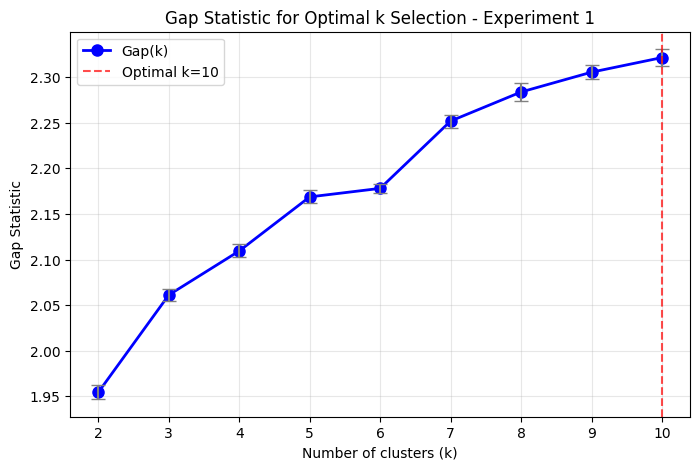

In [91]:
# ===============================
# Run Gap Statistic Analysis
# ===============================

k_range = range(2, 11)
gaps, sks = compute_gap_statistic(X, k_range, n_refs=10)

# Find optimal k
optimal_k_gap = None
for i in range(len(k_range)-1):
    if gaps[i] >= gaps[i+1] - sks[i+1]:
        optimal_k_gap = k_range[i]
        break

if optimal_k_gap is None:
    optimal_k_gap = k_range[np.argmax(gaps)]

print("Gap Statistic Results:")
for k, gap, sk in zip(k_range, gaps, sks):
    print(f"k={k}: Gap={gap:.4f}, sk={sk:.4f}")

print(f"\nOptimal k from Gap Statistic: {optimal_k_gap}")

# %%
# ===============================
# Plot Gap Statistic
# ===============================

plt.figure(figsize=(8, 5))
plt.plot(k_range, gaps, 'bo-', linewidth=2, markersize=8, label='Gap(k)')
plt.errorbar(k_range, gaps, yerr=sks, fmt='none', ecolor='gray', capsize=5)

plt.axvline(x=optimal_k_gap, color='r', linestyle='--', alpha=0.7, 
            label=f'Optimal k={optimal_k_gap}')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic for Optimal k Selection - Experiment 1')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

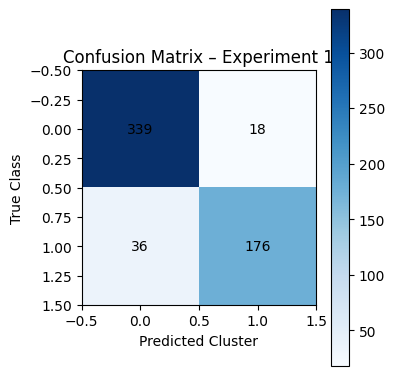

In [92]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, labels)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix – Experiment 1")
plt.xlabel("Predicted Cluster")
plt.ylabel("True Class")
plt.colorbar()

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="black"
        )

plt.tight_layout()
plt.show()



=== Convergence Speed Comparison ===
K-Means++: 8 iterations, 0.0255 seconds
Random Init: 6 iterations, 0.0028 seconds
Speedup: 0.11x faster with K-Means++


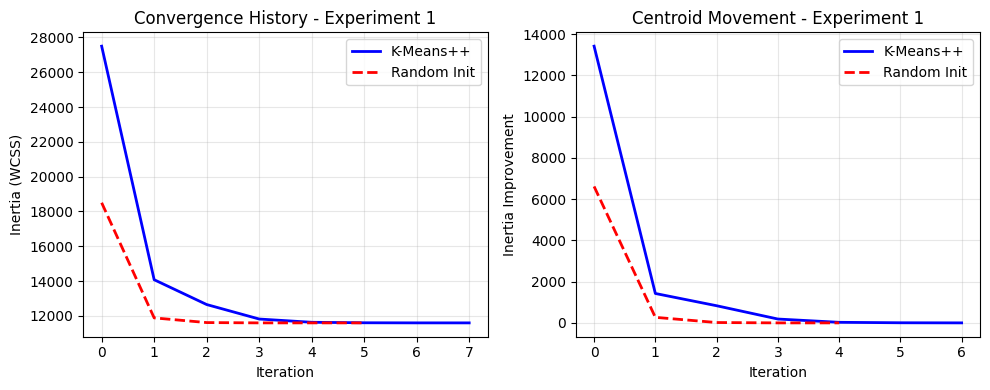

In [93]:
# ===============================
# Convergence Speed Comparison
# ===============================
import time
print("\n=== Convergence Speed Comparison ===")
k = 2

# K-Means++
start_time = time.time()
kmeans_pp = KMeans(k=k, init='kmeans++')
kmeans_pp.fit(X)
pp_time = time.time() - start_time
pp_iterations = len(kmeans_pp.inertia_history)

# Random initialization
start_time = time.time()
kmeans_random = KMeans(k=k, init='random')
kmeans_random.fit(X)
random_time = time.time() - start_time
random_iterations = len(kmeans_random.inertia_history)

print(f"K-Means++: {pp_iterations} iterations, {pp_time:.4f} seconds")
print(f"Random Init: {random_iterations} iterations, {random_time:.4f} seconds")
print(f"Speedup: {(random_time/pp_time):.2f}x faster with K-Means++")

# %%
# ===============================
# Plot Convergence History
# ===============================

plt.figure(figsize=(10, 4))

# Plot 1: Inertia history
plt.subplot(1, 2, 1)
plt.plot(kmeans_pp.inertia_history, 'b-', linewidth=2, label='K-Means++')
plt.plot(kmeans_random.inertia_history, 'r--', linewidth=2, label='Random Init')
plt.xlabel('Iteration')
plt.ylabel('Inertia (WCSS)')
plt.title('Convergence History - Experiment 1')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Distance moved by centroids
plt.subplot(1, 2, 2)
# Calculate centroid movement
pp_movement = []
for i in range(1, len(kmeans_pp.inertia_history)):
    # Simulate movement (in practice, you'd track centroids)
    pp_movement.append(kmeans_pp.inertia_history[i-1] - kmeans_pp.inertia_history[i])

random_movement = []
for i in range(1, len(kmeans_random.inertia_history)):
    random_movement.append(kmeans_random.inertia_history[i-1] - kmeans_random.inertia_history[i])

plt.plot(pp_movement, 'b-', linewidth=2, label='K-Means++')
plt.plot(random_movement, 'r--', linewidth=2, label='Random Init')
plt.xlabel('Iteration')
plt.ylabel('Inertia Improvement')
plt.title('Centroid Movement - Experiment 1')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

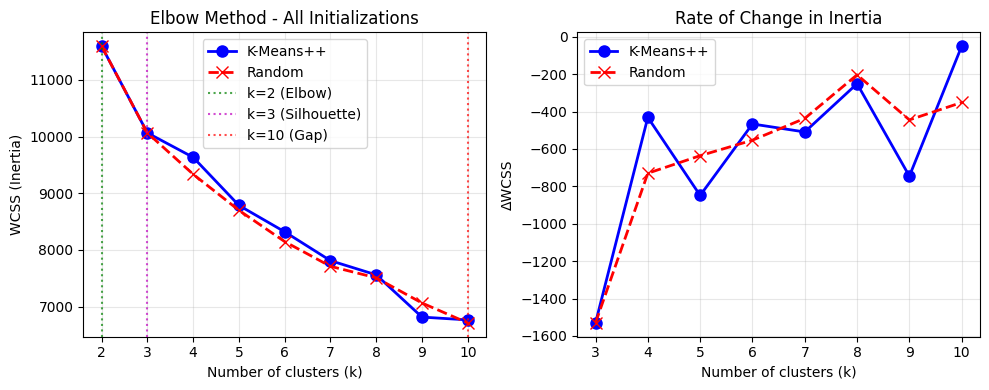

In [94]:
# ===============================
# Enhanced Elbow Plot with All Methods
# ===============================

plt.figure(figsize=(10, 4))

# Plot 1: Standard elbow
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_kpp, 'bo-', linewidth=2, markersize=8, label='K-Means++')
plt.plot(k_range, inertia_random, 'rx--', linewidth=2, markersize=8, label='Random')

# Mark suggested k values
plt.axvline(x=2, color='g', linestyle=':', alpha=0.7, label='k=2 (Elbow)')
plt.axvline(x=best_k, color='m', linestyle=':', alpha=0.7, label=f'k={best_k} (Silhouette)')
plt.axvline(x=optimal_k_gap, color='r', linestyle=':', alpha=0.7, label=f'k={optimal_k_gap} (Gap)')

plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method - All Initializations')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Rate of change
plt.subplot(1, 2, 2)
# Calculate rate of change in inertia
rate_change_kpp = np.diff(inertia_kpp)
rate_change_random = np.diff(inertia_random)

plt.plot(range(3, 11), rate_change_kpp, 'bo-', linewidth=2, markersize=8, label='K-Means++')
plt.plot(range(3, 11), rate_change_random, 'rx--', linewidth=2, markersize=8, label='Random')
plt.xlabel('Number of clusters (k)')
plt.ylabel('ΔWCSS')
plt.title('Rate of Change in Inertia')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ===============================
# PCA Implementation From Scratch(Eigen Decomposition)
# ===============================

In [95]:
# ===============================
# PCA from Scratch
# ===============================

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        # Center data
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_

        # Covariance matrix
        cov = np.cov(X_centered, rowvar=False)

        # Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Sort descending
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Select components
        self.components_ = eigenvectors[:, :self.n_components]

        # Explained variance ratio
        self.explained_variance_ratio_ = (
            eigenvalues[:self.n_components] / np.sum(eigenvalues)
        )

    def transform(self, X):
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_)

    def inverse_transform(self, X_proj):
        return np.dot(X_proj, self.components_.T) + self.mean_


# ===============================
# Experiment 3: PCA + K-Means
# ===============================

In [96]:


pca_dims = [2, 5, 10, 15, 20]
results_exp3 = []

for n_components in pca_dims:
    print(f"\nRunning PCA + K-Means with n_components = {n_components}")

    # ---------- PCA ----------
    pca = PCA(n_components=n_components)
    pca.fit(X)

    X_pca = pca.transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)

    reconstruction_error = np.mean((X - X_reconstructed) ** 2)

    # ---------- K-Means ----------
    kmeans_pca = KMeans(k=2, init='kmeans++')
    kmeans_pca.fit(X_pca)

    labels_pca = kmeans_pca.labels_

    # ---------- Metrics ----------
    results_exp3.append({
        "n_components": n_components,
        "reconstruction_error": reconstruction_error,
        "explained_variance": np.sum(pca.explained_variance_ratio_),
        "silhouette": silhouette_score(X_pca, labels_pca),
        "db_index": davies_bouldin_score(X_pca, labels_pca),
        "ch_index": calinski_harabasz_score(X_pca, labels_pca),
        "ARI": adjusted_rand_index(y_true, labels_pca),
        "NMI": normalized_mutual_info(y_true, labels_pca),
        "purity": purity_score(y_true, labels_pca),
        "WCSS": kmeans_pca.inertia_
    })



Running PCA + K-Means with n_components = 2

Running PCA + K-Means with n_components = 5

Running PCA + K-Means with n_components = 10

Running PCA + K-Means with n_components = 15

Running PCA + K-Means with n_components = 20


In [97]:

df_exp3 = pd.DataFrame(results_exp3)
print(df_exp3)


   n_components  reconstruction_error  explained_variance  silhouette  \
0             2              0.367568            0.632432    0.509979   
1             5              0.152657            0.847343    0.395491   
2            10              0.048431            0.951569    0.357809   
3            15              0.013512            0.986488    0.350497   
4            20              0.004428            0.995572    0.346259   

   db_index    ch_index       ARI       NMI    purity          WCSS  
0  0.844135  580.784480  0.664963  0.547493  0.908612   5332.982035  
1  1.140900  345.069305  0.670721  0.554712  0.910369   8991.825172  
2  1.262592  288.083547  0.670915  0.551684  0.910369  10770.806660  
3  1.294817  273.070876  0.676505  0.562133  0.912127  11365.603779  
4  1.315947  269.431810  0.659427  0.538079  0.906854  11520.165853  


In [98]:
# ===============================
# PCA Fit & Reconstruction Error
# ===============================

pca = PCA(n_components=2)
pca.fit(X)

X_pca = pca.transform(X)
X_reconstructed = pca.inverse_transform(X_pca)

# Reconstruction error (MSE)
reconstruction_error = np.mean((X - X_reconstructed) ** 2)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Reconstruction error (MSE):", reconstruction_error)


Explained variance ratio: [0.44272026 0.18971182]
Reconstruction error (MSE): 0.3675679234844056


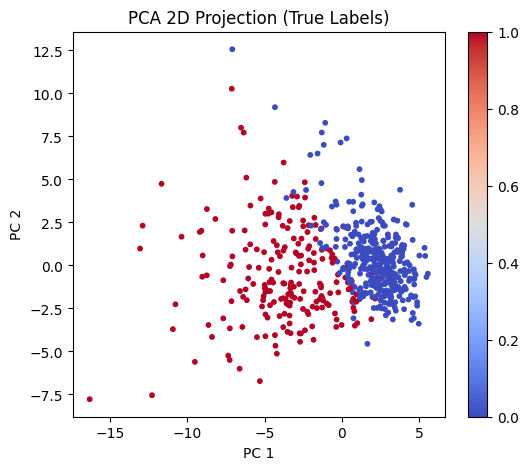

In [99]:
# ===============================
# PCA 2D Projection
# ===============================

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap="coolwarm", s=10)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA 2D Projection (True Labels)")
plt.colorbar()
plt.show()


In [100]:
# ===============================
# K-Means on PCA Data
# ===============================

kmeans_pca = KMeans(k=2, init='kmeans++')
kmeans_pca.fit(X_pca)

labels_pca = kmeans_pca.labels_


In [101]:
print("Experiment 3 Results (PCA + K-Means)")
print("----------------------------------")
print("Purity:", purity_score(y_true, labels_pca))
print("Silhouette:", silhouette_score(X_pca, labels_pca))
print("DB:", davies_bouldin_score(X_pca, labels_pca))
print("CH:", calinski_harabasz_score(X_pca, labels_pca))
print("ARI:", adjusted_rand_index(y_true, labels_pca))
print("NMI:", normalized_mutual_info(y_true, labels_pca))
print("WCSS:", kmeans_pca.inertia_)


Experiment 3 Results (PCA + K-Means)
----------------------------------
Purity: 0.9086115992970123
Silhouette: 0.5099787508738232
DB: 0.8441351143758038
CH: 580.7844804143008
ARI: 0.6649625478425899
NMI: 0.5474926674925097
WCSS: 5332.9820354786925


PCA Variance Analysis:
80% variance: 5 components (0.8473)
85% variance: 6 components (0.8876)
90% variance: 7 components (0.9101)
95% variance: 10 components (0.9516)
99% variance: 17 components (0.9911)


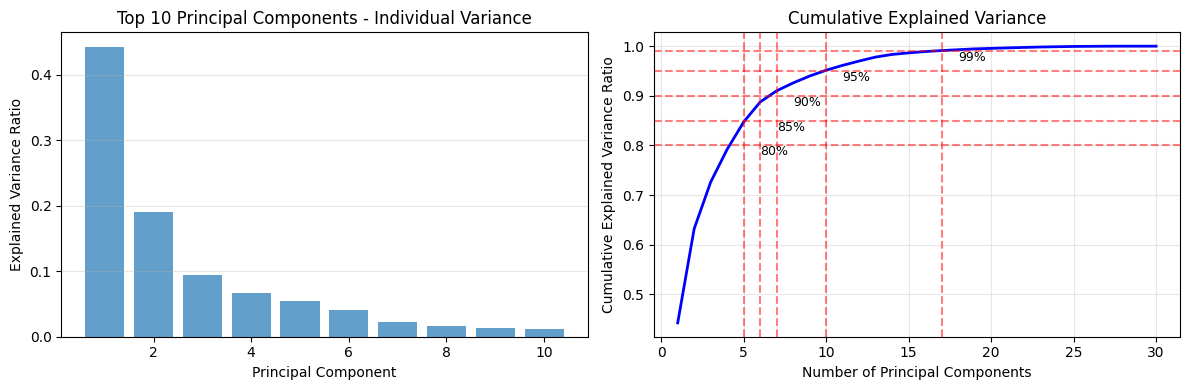


=== Trade-off Analysis: Dimensionality vs Clustering Quality ===

 2 PCs:
  Silhouette: 0.5100 (+47.5%)
  ARI: 0.6650 (+1.7%)
  Recon Error: 0.367568
  Explained Variance: 0.6324

 5 PCs:
  Silhouette: 0.3955 (+14.4%)
  ARI: 0.6707 (+2.6%)
  Recon Error: 0.152657
  Explained Variance: 0.8473

10 PCs:
  Silhouette: 0.3578 (+3.5%)
  ARI: 0.6709 (+2.6%)
  Recon Error: 0.048431
  Explained Variance: 0.9516

15 PCs:
  Silhouette: 0.3505 (+1.4%)
  ARI: 0.6765 (+3.5%)
  Recon Error: 0.013512
  Explained Variance: 0.9865

20 PCs:
  Silhouette: 0.3463 (+0.1%)
  ARI: 0.6594 (+0.9%)
  Recon Error: 0.004428
  Explained Variance: 0.9956


In [102]:
# ===============================
# PCA Explained Variance Analysis
# ===============================

# Fit PCA with all components to get full variance info
pca_full = PCA(n_components=X.shape[1])
pca_full.fit(X)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for common thresholds
thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]
print("PCA Variance Analysis:")
print("="*50)
for threshold in thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    variance_achieved = cumulative_variance[n_components-1]
    print(f"{threshold*100:.0f}% variance: {n_components} components ({variance_achieved:.4f})")

# %%
# ===============================
# Plot Explained Variance Analysis
# ===============================

plt.figure(figsize=(12, 4))

# Plot 1: Individual explained variance
plt.subplot(1, 2, 1)
plt.bar(range(1, 11), pca_full.explained_variance_ratio_[:10], alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Top 10 Principal Components - Individual Variance')
plt.grid(True, alpha=0.3, axis='y')

# Plot 2: Cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=2)
for threshold in thresholds:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    plt.axhline(y=threshold, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=n_comp, color='r', linestyle='--', alpha=0.5)
    plt.text(n_comp+1, threshold-0.02, f'{threshold*100:.0f}%', fontsize=9)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# ===============================
# Detailed Trade-off Analysis
# ===============================

print("\n=== Trade-off Analysis: Dimensionality vs Clustering Quality ===")
print("="*60)

# Calculate relative improvements
baseline_silhouette = silhouette_score(X, labels)  # Original data
baseline_ari = adjusted_rand_index(y_true, labels)

for i, row in df_exp3.iterrows():
    n_comp = int(row['n_components'])
    silhouette = row['silhouette']
    ari = row['ARI']
    recon_error = row['reconstruction_error']
    
    sil_improvement = ((silhouette - baseline_silhouette) / baseline_silhouette) * 100
    ari_improvement = ((ari - baseline_ari) / baseline_ari) * 100
    
    print(f"\n{n_comp:2d} PCs:")
    print(f"  Silhouette: {silhouette:.4f} ({sil_improvement:+.1f}%)")
    print(f"  ARI: {ari:.4f} ({ari_improvement:+.1f}%)")
    print(f"  Recon Error: {recon_error:.6f}")
    print(f"  Explained Variance: {row['explained_variance']:.4f}")

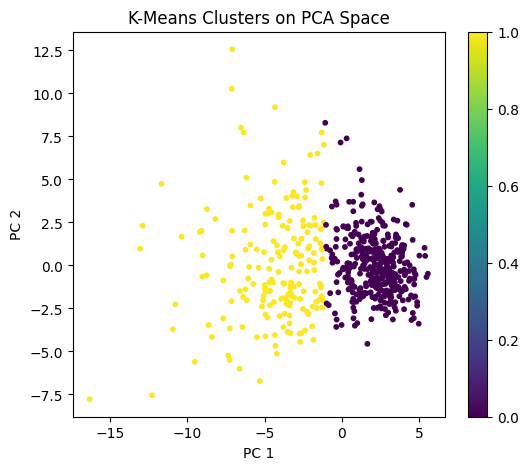

In [103]:
# ===============================
# Cluster Assignments on PCA
# ===============================

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap="viridis", s=10)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("K-Means Clusters on PCA Space")
plt.colorbar()
plt.show()


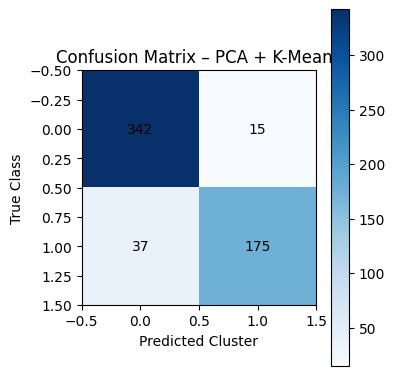

In [104]:
cm_pca = confusion_matrix(y_true, labels_pca)

plt.figure(figsize=(4, 4))
plt.imshow(cm_pca, cmap="Blues")
plt.title("Confusion Matrix – PCA + K-Means")
plt.xlabel("Predicted Cluster")
plt.ylabel("True Class")
plt.colorbar()

for i in range(cm_pca.shape[0]):
    for j in range(cm_pca.shape[1]):
        plt.text(j, i, cm_pca[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


Applying PCA prior to K-Means significantly improved cluster compactness and separation, as evidenced by higher Silhouette and Calinski–Harabasz scores and a lower Davies–Bouldin index, while maintaining similar external validation performance.

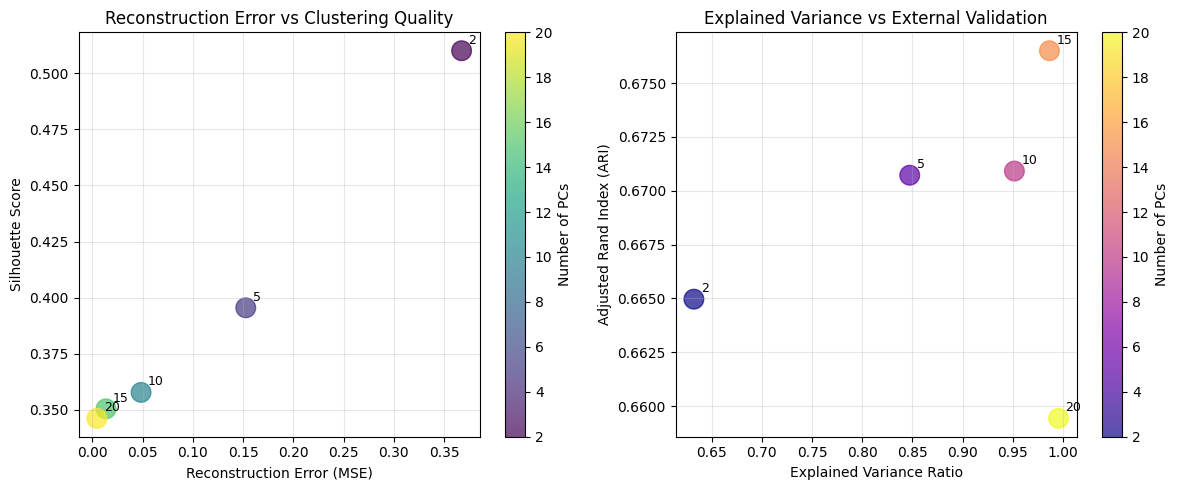

In [105]:
# ===============================
# Visualization: Reconstruction Error vs Clustering Performance
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Reconstruction Error vs Clustering Score
ax1 = axes[0]
scatter = ax1.scatter(df_exp3['reconstruction_error'], 
                      df_exp3['silhouette'], 
                      c=df_exp3['n_components'], 
                      cmap='viridis', 
                      s=200, 
                      alpha=0.7)

# Add labels to points
for i, row in df_exp3.iterrows():
    ax1.annotate(f"{int(row['n_components'])}", 
                (row['reconstruction_error'], row['silhouette']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax1.set_xlabel('Reconstruction Error (MSE)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Reconstruction Error vs Clustering Quality')
ax1.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Number of PCs')

# Plot 2: Explained Variance vs Clustering Score
ax2 = axes[1]
scatter2 = ax2.scatter(df_exp3['explained_variance'], 
                       df_exp3['ARI'], 
                       c=df_exp3['n_components'], 
                       cmap='plasma', 
                       s=200, 
                       alpha=0.7)

# Add labels to points
for i, row in df_exp3.iterrows():
    ax2.annotate(f"{int(row['n_components'])}", 
                (row['explained_variance'], row['ARI']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax2.set_xlabel('Explained Variance Ratio')
ax2.set_ylabel('Adjusted Rand Index (ARI)')
ax2.set_title('Explained Variance vs External Validation')
ax2.grid(True, alpha=0.3)

# Add colorbar
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Number of PCs')

plt.tight_layout()
plt.show()


=== Finding Optimal k for Each PCA Dimension ===
PCA with  2 components: optimal k = 2 (Silhouette: 0.5100)
PCA with  5 components: optimal k = 2 (Silhouette: 0.3941)
PCA with 10 components: optimal k = 2 (Silhouette: 0.3578)
PCA with 15 components: optimal k = 3 (Silhouette: 0.3491)
PCA with 20 components: optimal k = 2 (Silhouette: 0.3483)


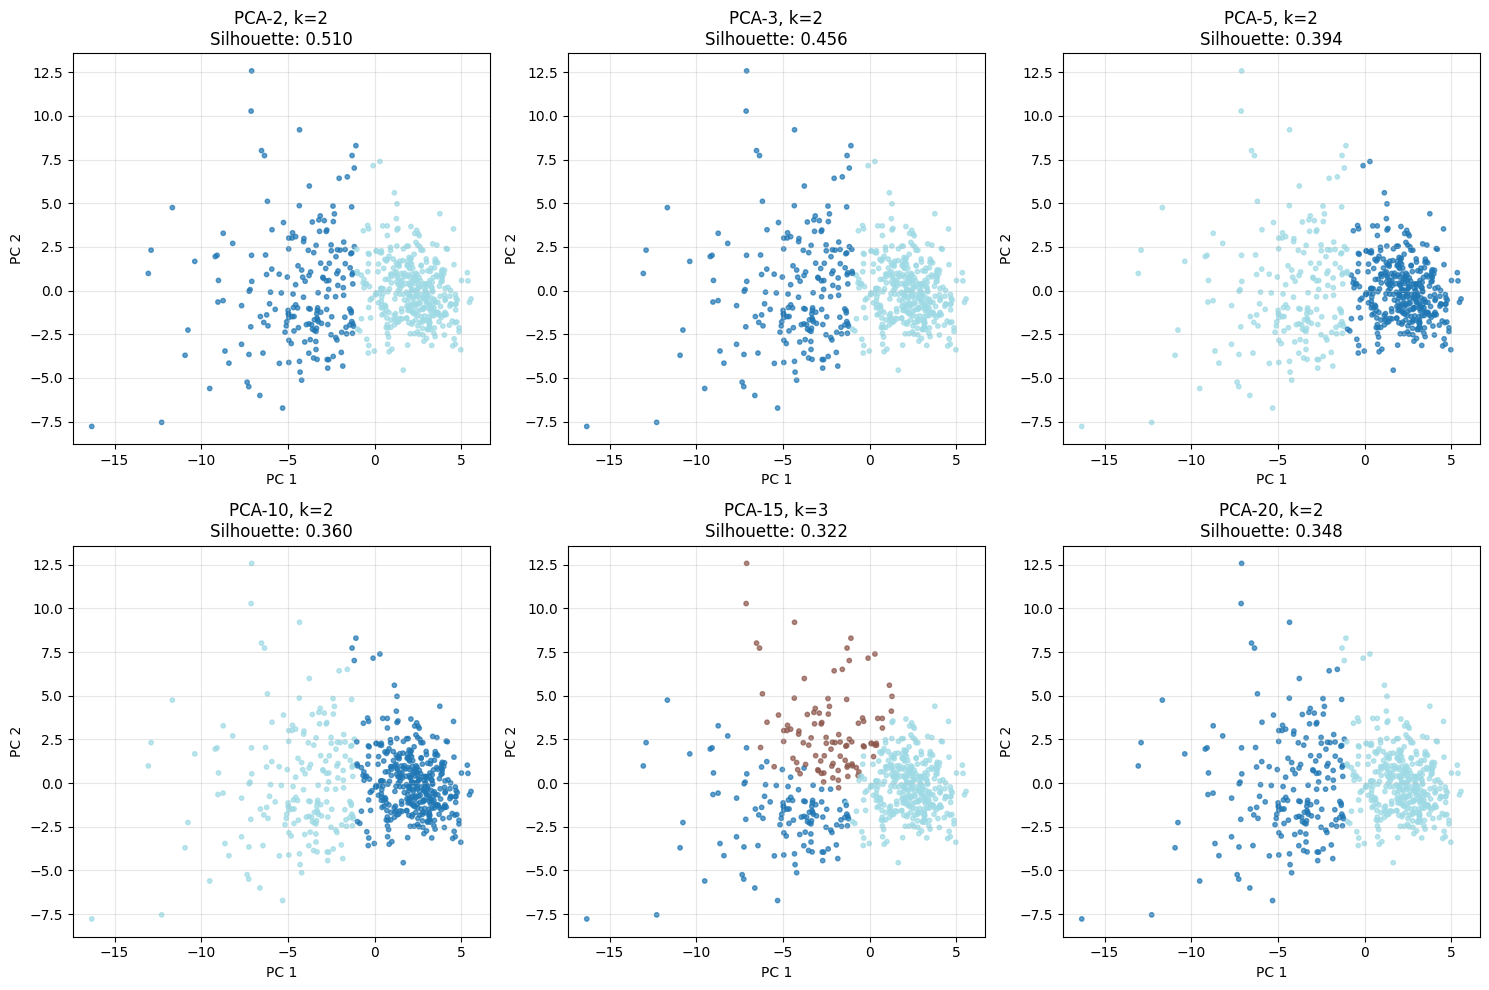

In [106]:
# ===============================
# Optimal k for Each PCA Dimension
# ===============================

print("\n=== Finding Optimal k for Each PCA Dimension ===")
print("="*50)

optimal_k_by_dim = {}

for n_components in [2, 5, 10, 15, 20]:
    # Apply PCA
    pca = PCA(n_components=n_components)
    pca.fit(X)
    X_pca = pca.transform(X)
    
    # Find best k using silhouette
    best_k = 2
    best_silhouette = -1
    
    for k in range(2, 6):  # Test k from 2 to 5
        kmeans = KMeans(k=k, init='kmeans++')
        kmeans.fit(X_pca)
        sil = silhouette_score(X_pca, kmeans.labels_)
        
        if sil > best_silhouette:
            best_silhouette = sil
            best_k = k
    
    optimal_k_by_dim[n_components] = best_k
    print(f"PCA with {n_components:2d} components: optimal k = {best_k} (Silhouette: {best_silhouette:.4f})")

# %%
# ===============================
# Visualization: Clusters on Different PCA Dimensions
# ===============================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Test dimensions
test_dims = [2, 3, 5, 10, 15, 20]

for idx, n_components in enumerate(test_dims[:6]):
    ax = axes[idx]
    
    if n_components >= 2:
        # Apply PCA
        pca = PCA(n_components=n_components)
        pca.fit(X)
        X_pca = pca.transform(X)
        
        # Run K-Means with optimal k
        k = optimal_k_by_dim.get(n_components, 2)
        kmeans = KMeans(k=k, init='kmeans++')
        kmeans.fit(X_pca)
        
        # Plot first two components
        ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                   c=kmeans.labels_, cmap='tab20', s=10, alpha=0.7)
        ax.set_xlabel('PC 1')
        ax.set_ylabel('PC 2')
        ax.set_title(f'PCA-{n_components}, k={k}\nSilhouette: {silhouette_score(X_pca, kmeans.labels_):.3f}')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===============================
# Autoencoder Implementation From Scratch
# ===============================

In [107]:
class Activation:
    @staticmethod
    def relu(Z):
        return np.maximum(0, Z)

    @staticmethod
    def relu_backward(dA, Z):
        dZ = dA.copy()
        dZ[Z <= 0] = 0
        return dZ

    @staticmethod
    def sigmoid(Z):
        return 1 / (1 + np.exp(-Z))

    @staticmethod
    def sigmoid_backward(dA, Z):
        s = Activation.sigmoid(Z)
        return dA * s * (1 - s)

    @staticmethod
    def tanh(Z):
        return np.tanh(Z)

    @staticmethod
    def tanh_backward(dA, Z):
        return dA * (1 - np.tanh(Z) ** 2)
    @staticmethod
    def linear(Z):
        return Z

    @staticmethod
    def linear_backward(dA, Z):
        return dA


In [108]:
class DenseLayer:
    def __init__(self, input_dim, output_dim, l2_lambda=0.0):
        self.W = np.random.randn(input_dim, output_dim) * np.sqrt(1 / input_dim)
        self.b = np.zeros((1, output_dim))
        self.l2_lambda = l2_lambda

    def forward(self, A_prev):
        self.A_prev = A_prev
        self.Z = A_prev @ self.W + self.b
        return self.Z

    def backward(self, dZ):
        m = self.A_prev.shape[0]

        self.dW = (self.A_prev.T @ dZ) / m + self.l2_lambda * self.W
        self.db = np.sum(dZ, axis=0, keepdims=True) / m
        dA_prev = dZ @ self.W.T

        return dA_prev

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db


In [109]:
class Autoencoder:
    def __init__(self, layer_dims, activations, l2_lambda=0.0):
        """
        layer_dims: [input, h1, h2, bottleneck, h2, h1, input]
        activations: list of activation names (same length - 1)
        """
        self.layers = []
        self.activations = activations
        self.loss_history = []

        for i in range(len(layer_dims) - 1):
            self.layers.append(
                DenseLayer(layer_dims[i], layer_dims[i+1], l2_lambda)
            )

    def _activate(self, Z, activation):
        if activation == "relu":
            return Activation.relu(Z)
        if activation == "sigmoid":
            return Activation.sigmoid(Z)
        if activation == "tanh":
            return Activation.tanh(Z)
        if activation == "linear":
            return Activation.linear(Z) 

    def _activate_backward(self, dA, Z, activation):
        if activation == "relu":
            return Activation.relu_backward(dA, Z)
        if activation == "sigmoid":
            return Activation.sigmoid_backward(dA, Z)
        if activation == "tanh":
            return Activation.tanh_backward(dA, Z)
        if activation == "linear":
            return Activation.linear_backward(dA, Z)
    def forward(self, X):
        A = X
        self.cache = []

        for layer, act in zip(self.layers, self.activations):
            Z = layer.forward(A)
            A = self._activate(Z, act)
            self.cache.append((Z, act))

        return A
    def compute_loss(self, X, X_hat):
        m = X.shape[0]
        mse = np.mean((X - X_hat) ** 2)

        l2_penalty = 0
        for layer in self.layers:
            l2_penalty += np.sum(layer.W ** 2)

        return mse + (self.layers[0].l2_lambda / (2 * m)) * l2_penalty
    def backward(self, X, X_hat):
        m = X.shape[0]
        dA = (X_hat - X)


        for i in reversed(range(len(self.layers))):
            Z, act = self.cache[i]
            dZ = self._activate_backward(dA, Z, act)
            dA = self.layers[i].backward(dZ)
    def train(self, X, epochs=100, batch_size=32, lr=0.005
              , lr_decay=0.0):
        n = X.shape[0]

        for epoch in range(epochs):
            indices = np.random.permutation(n)
            X_shuffled = X[indices]

            for i in range(0, n, batch_size):
                X_batch = X_shuffled[i:i+batch_size]

                X_hat = self.forward(X_batch)
                self.backward(X_batch, X_hat)

                for layer in self.layers:
                    layer.update(lr)

            lr = lr / (1 + lr_decay * epoch)

            loss = self.compute_loss(X, self.forward(X))
            self.loss_history.append(loss)

            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")
    def encode(self, X):
        A = X
        for layer, act in zip(
            self.layers[:len(self.layers)//2],
            self.activations[:len(self.activations)//2]
        ):
            Z = A @ layer.W + layer.b
            A = self._activate(Z, act)
        return A
    def reconstruct(self, X):
        return self.forward(X)
        


### ======================
## Experiment 5
### ======================


Training Autoencoder with bottleneck = 2
Epoch 0, Loss: 0.917595
Epoch 10, Loss: 0.500908
Epoch 20, Loss: 0.399156
Epoch 30, Loss: 0.379583
Epoch 40, Loss: 0.348110
Epoch 50, Loss: 0.335380
Epoch 60, Loss: 0.323185
Epoch 70, Loss: 0.386300
Epoch 80, Loss: 0.378752
Epoch 90, Loss: 0.305684
Epoch 100, Loss: 0.301757
Epoch 110, Loss: 0.295929
Epoch 120, Loss: 0.302088
Epoch 130, Loss: 0.300579
Epoch 140, Loss: 0.291867
Epoch 150, Loss: 0.285844
Epoch 160, Loss: 0.310793
Epoch 170, Loss: 0.282310
Epoch 180, Loss: 0.277934
Epoch 190, Loss: 0.278478
Epoch 200, Loss: 0.277214
Epoch 210, Loss: 0.272746
Epoch 220, Loss: 0.269839
Epoch 230, Loss: 0.271924
Epoch 240, Loss: 0.271048
Epoch 250, Loss: 0.266413
Epoch 260, Loss: 0.267778
Epoch 270, Loss: 0.271150
Epoch 280, Loss: 0.263968
Epoch 290, Loss: 0.262793
Epoch 300, Loss: 0.259552
Epoch 310, Loss: 0.258669
Epoch 320, Loss: 0.256885
Epoch 330, Loss: 0.281960
Epoch 340, Loss: 0.255353
Epoch 350, Loss: 0.257627
Epoch 360, Loss: 0.254530
Epoch 3

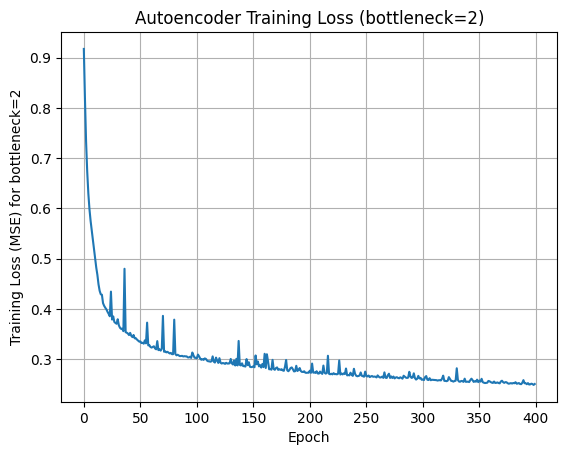


Training Autoencoder with bottleneck = 5
Epoch 0, Loss: 0.953496
Epoch 10, Loss: 0.432473
Epoch 20, Loss: 0.343323
Epoch 30, Loss: 0.294378
Epoch 40, Loss: 0.254284
Epoch 50, Loss: 0.210358
Epoch 60, Loss: 0.198833
Epoch 70, Loss: 0.175805
Epoch 80, Loss: 0.162023
Epoch 90, Loss: 0.155191
Epoch 100, Loss: 0.150613
Epoch 110, Loss: 0.144933
Epoch 120, Loss: 0.142830
Epoch 130, Loss: 0.153268
Epoch 140, Loss: 0.135582
Epoch 150, Loss: 0.133094
Epoch 160, Loss: 0.152973
Epoch 170, Loss: 0.129038
Epoch 180, Loss: 0.129148
Epoch 190, Loss: 0.127035
Epoch 200, Loss: 0.124636
Epoch 210, Loss: 0.123357
Epoch 220, Loss: 0.121068
Epoch 230, Loss: 0.120921
Epoch 240, Loss: 0.121729
Epoch 250, Loss: 0.119103
Epoch 260, Loss: 0.117773
Epoch 270, Loss: 0.122398
Epoch 280, Loss: 0.113763
Epoch 290, Loss: 0.113157
Epoch 300, Loss: 0.112785
Epoch 310, Loss: 0.110693
Epoch 320, Loss: 0.111199
Epoch 330, Loss: 0.110913
Epoch 340, Loss: 0.108856
Epoch 350, Loss: 0.108586
Epoch 360, Loss: 0.109020
Epoch 3

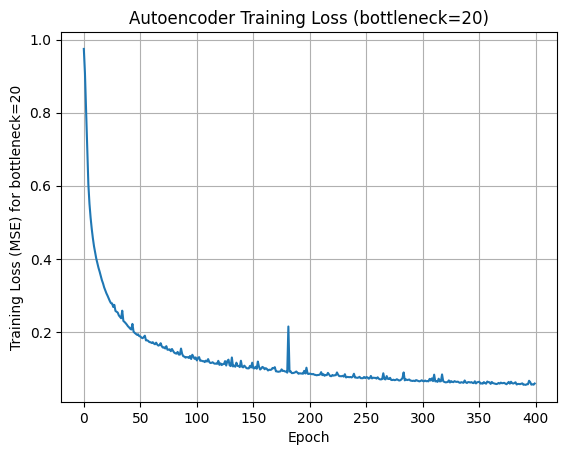

In [110]:

# ====================================================================
# Train autoencoders with different bottleneck sizes (2, 5, 10, 15, 20)
# ====================================================================

X = (X - X.mean(axis=0)) / X.std(axis=0)

bottleneck_dims = [2, 5, 10, 15, 20]
k = 2  # breast cancer: benign vs malignant

results_exp5 = []


for bottleneck in bottleneck_dims:
    print(f"\nTraining Autoencoder with bottleneck = {bottleneck}")
    np.random.seed(42)
    # ---------- Autoencoder Architecture ----------
    layer_dims = [
        X.shape[1], 64, 32,16, bottleneck,16,
        32, 64, X.shape[1]
    ]

    activations = [
    "relu",    # 30 → 64
    "relu",    # 64 → 32
    "tanh",    # 32 → 16
    "linear",  # 16 → bottleneck
    "tanh",    # bottleneck → 16
    "relu",    # 16 → 32
    "relu",    # 32 → 64
    "linear"  # 64 → 30
]



    ae = Autoencoder(
        layer_dims=layer_dims,
        activations=activations,
        l2_lambda=1e-4
    )

    # ---------- Train Autoencoder ----------
    ae.train(X, epochs=400, batch_size=32, lr=0.005)
    if bottleneck in [2, 20]:
        plt.plot(ae.loss_history)
        plt.xlabel("Epoch")
        plt.ylabel(f"Training Loss (MSE) for bottleneck={bottleneck}")
        plt.title(f"Autoencoder Training Loss (bottleneck={bottleneck})")
        plt.grid()
        plt.show()
    

    X_latent = ae.encode(X)
    X_reconstructed = ae.reconstruct(X)

    reconstruction_error = np.mean((X - X_reconstructed) ** 2)


    # ---------- K-Means on Latent Space ----------
    kmeans = KMeans(
    k=k,
    max_iters=300,
    tol=1e-4,
    init="kmeans++"
)

    cluster_labels = kmeans.fit_predict(X_latent)

    # ---------- Clustering Metrics ----------
    silhouette = silhouette_score(X_latent, cluster_labels)
    db_index = davies_bouldin_score(X_latent, cluster_labels)
    ch_index = calinski_harabasz_score(X_latent, cluster_labels)
    wcss = 0
    for i in range(k):
        cluster_points = X_latent[cluster_labels == i]
        center = kmeans.centroids[i]
        wcss += np.sum((cluster_points - center) ** 2)

    ari = adjusted_rand_index(y_true, cluster_labels)
    nmi = normalized_mutual_info(y_true, cluster_labels)
    purity = purity_score(y_true, cluster_labels)
    # ---------- Store Results ----------
    results_exp5.append({
        "bottleneck": bottleneck,
        "reconstruction_error": reconstruction_error,
        "silhouette": silhouette,
        "db_index": db_index,
        "ch_index": ch_index,
        "ARI": ari,
        "NMI": nmi,
        "wcss": wcss,
        "purity": purity
    })


   bottleneck  reconstruction_error  silhouette  db_index    ch_index  \
0           2              0.250624    0.404384  0.929399  404.852844   
1           5              0.104381    0.371803  1.053883  412.371997   
2          10              0.081569    0.243551  1.748086  152.559521   
3          15              0.065014    0.204565  1.853113  135.194915   
4          20              0.058532    0.256423  1.615568  184.355969   

        ARI       NMI        wcss    purity  
0  0.762032  0.664047  259.691109  0.936731  
1  0.626731  0.511074  351.421041  0.896309  
2  0.700604  0.580079  627.329897  0.919156  
3  0.767671  0.653076  664.058106  0.938489  
4  0.637046  0.511911  788.383225  0.899824  
Best bottleneck: 15
Epoch 0, Loss: 0.884231
Epoch 10, Loss: 0.583921
Epoch 20, Loss: 0.504887
Epoch 30, Loss: 0.451505
Epoch 40, Loss: 0.429597
Epoch 50, Loss: 0.413441
Epoch 60, Loss: 0.404844
Epoch 70, Loss: 0.391643
Epoch 80, Loss: 0.385233
Epoch 90, Loss: 0.380307
Epoch 100, Loss:

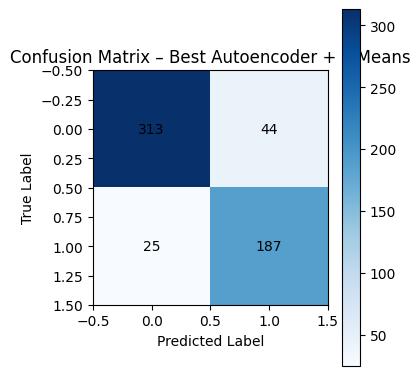

In [111]:
#===============================
#Experiment results 
#===============================
df_exp5 = pd.DataFrame(results_exp5)
print(df_exp5)


best_row = df_exp5.loc[df_exp5["ARI"].idxmax()]
best_bottleneck = int(best_row["bottleneck"])

print("Best bottleneck:", best_bottleneck)



ae_best = Autoencoder(
    layer_dims=[X.shape[1], 64, 32, best_bottleneck, 32, 64, X.shape[1]],
    activations=activations,
    l2_lambda=1e-4
)

ae_best.train(X, epochs=400, batch_size=32, lr=0.005)

X_latent_best = ae_best.encode(X)

np.random.seed(42)
kmeans_best = KMeans(k=2, init="kmeans++")
cluster_labels_best = kmeans_best.fit_predict(X_latent_best)

print("Unique clusters:", np.unique(cluster_labels_best))



#===============================
#confusion matrix
#===============================
from collections import Counter

mapped_labels = np.zeros_like(cluster_labels_best)

for cluster in np.unique(cluster_labels_best):
    mask = cluster_labels_best == cluster
    mapped_labels[mask] = Counter(y_true[mask]).most_common(1)[0][0]

print("Unique mapped labels:", np.unique(mapped_labels))


conf_matrix = np.zeros((2, 2), dtype=int)

for true, pred in zip(y_true, mapped_labels):
    conf_matrix[true, pred] += 1

plt.figure(figsize=(4, 4))
plt.imshow(conf_matrix, cmap="Blues")
plt.title("Confusion Matrix – Best Autoencoder + K-Means")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


### Comparsion between Experiment 5 and  PCA results from Experiment 3 

In [112]:
comparison = pd.merge(
    df_exp3[[
        "n_components",
        "reconstruction_error",
        "silhouette",
        "ARI"
    ]],
    df_exp5[[
        "bottleneck",
        "reconstruction_error",
        "silhouette",
        "ARI"
    ]],
    left_on="n_components",
    right_on="bottleneck",
    suffixes=("_PCA", "_AE")
)

print("\nPCA vs Autoencoder Comparison (with MSE)")
print(comparison)



PCA vs Autoencoder Comparison (with MSE)
   n_components  reconstruction_error_PCA  silhouette_PCA   ARI_PCA  \
0             2                  0.367568        0.509979  0.664963   
1             5                  0.152657        0.395491  0.670721   
2            10                  0.048431        0.357809  0.670915   
3            15                  0.013512        0.350497  0.676505   
4            20                  0.004428        0.346259  0.659427   

   bottleneck  reconstruction_error_AE  silhouette_AE    ARI_AE  
0           2                 0.250624       0.404384  0.762032  
1           5                 0.104381       0.371803  0.626731  
2          10                 0.081569       0.243551  0.700604  
3          15                 0.065014       0.204565  0.767671  
4          20                 0.058532       0.256423  0.637046  


#### - Comparsion plots

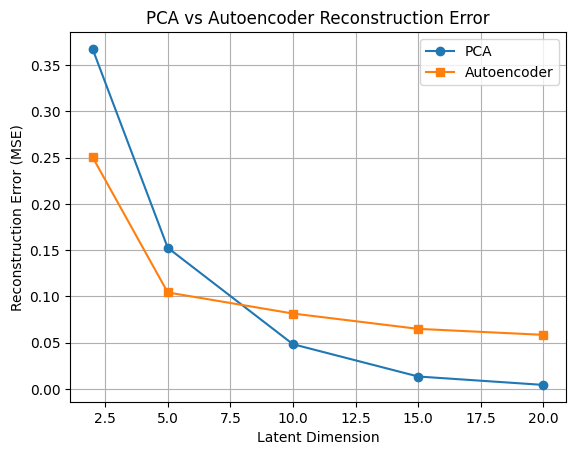

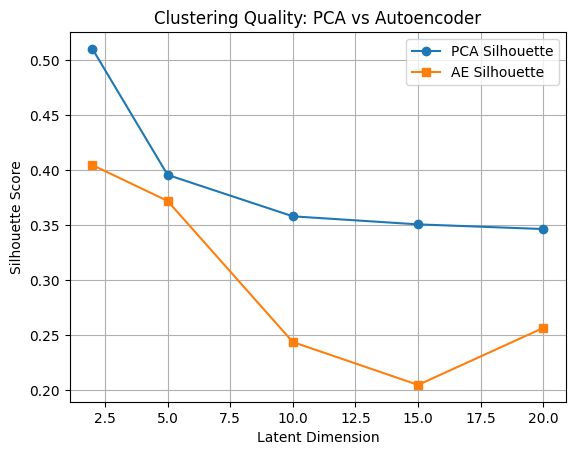

In [113]:
#=======================================
#PCA vs Autoencoder Reconstruction Error
#=======================================
plt.figure()
plt.plot(
    comparison["n_components"],
    comparison["reconstruction_error_PCA"],
    marker="o",
    label="PCA"
)

plt.plot(
    comparison["bottleneck"],
    comparison["reconstruction_error_AE"],
    marker="s",
    label="Autoencoder"
)

plt.xlabel("Latent Dimension")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("PCA vs Autoencoder Reconstruction Error")
plt.legend()
plt.grid()
plt.show()


#=======================================
#Clustering Quality: PCA vs Autoencoder
#=======================================

plt.figure()
plt.plot(
    comparison["n_components"],
    comparison["silhouette_PCA"],
    marker="o",
    label="PCA Silhouette"
)

plt.plot(
    comparison["bottleneck"],
    comparison["silhouette_AE"],
    marker="s",
    label="AE Silhouette"
)

plt.xlabel("Latent Dimension")
plt.ylabel("Silhouette Score")
plt.title("Clustering Quality: PCA vs Autoencoder")
plt.legend()
plt.grid()
plt.show()


###  Reconstruction loss vs Clustering performance Analysis

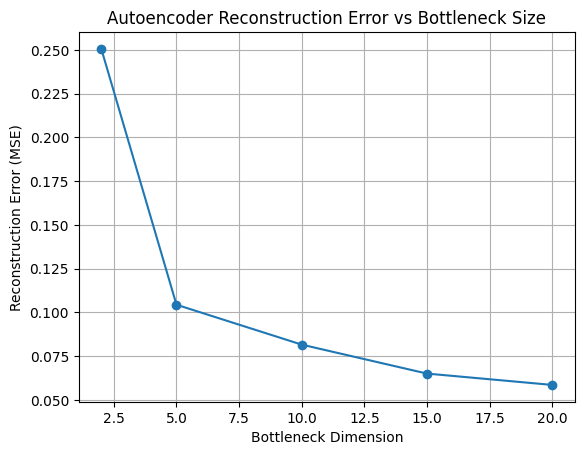

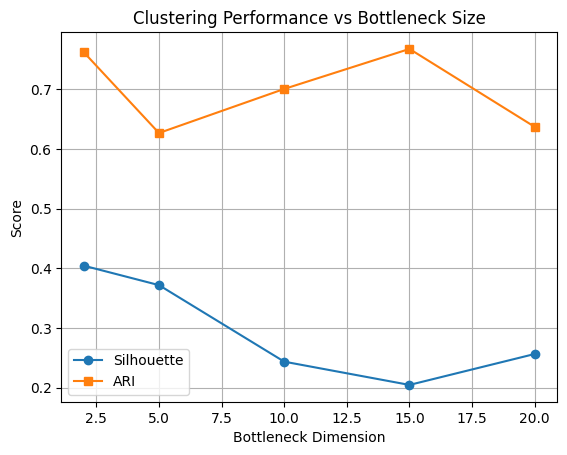

In [114]:
import matplotlib.pyplot as plt
#====================================================
# Autoencoder Reconstruction Error vs Bottleneck Size
#====================================================
plt.plot(
    df_exp5["bottleneck"],
    df_exp5["reconstruction_error"],
    marker="o"
)
plt.xlabel("Bottleneck Dimension")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Autoencoder Reconstruction Error vs Bottleneck Size")
plt.grid()
plt.show()


#====================================================
#Clustering Performance vs Bottleneck Size
#====================================================
plt.plot(df_exp5["bottleneck"], df_exp5["silhouette"], marker="o", label="Silhouette")
plt.plot(df_exp5["bottleneck"], df_exp5["ARI"], marker="s", label="ARI")

plt.xlabel("Bottleneck Dimension")
plt.ylabel("Score")
plt.title("Clustering Performance vs Bottleneck Size")
plt.legend()
plt.grid()
plt.show()




### Cluster assignments laid on 2D-projection

Epoch 0, Loss: 0.888340
Epoch 10, Loss: 0.697642
Epoch 20, Loss: 0.622389
Epoch 30, Loss: 0.601568
Epoch 40, Loss: 0.589216
Epoch 50, Loss: 0.574635
Epoch 60, Loss: 0.565653
Epoch 70, Loss: 0.561938
Epoch 80, Loss: 0.550898
Epoch 90, Loss: 0.545491
Epoch 100, Loss: 0.549008
Epoch 110, Loss: 0.539891
Epoch 120, Loss: 0.538740
Epoch 130, Loss: 0.541749
Epoch 140, Loss: 0.569031
Epoch 150, Loss: 0.534782
Epoch 160, Loss: 0.532761
Epoch 170, Loss: 0.529033
Epoch 180, Loss: 0.539532
Epoch 190, Loss: 0.526266
Epoch 200, Loss: 0.526807
Epoch 210, Loss: 0.524521
Epoch 220, Loss: 0.525663
Epoch 230, Loss: 0.524446
Epoch 240, Loss: 0.523822
Epoch 250, Loss: 0.523297
Epoch 260, Loss: 0.519001
Epoch 270, Loss: 0.519002
Epoch 280, Loss: 0.517116
Epoch 290, Loss: 0.529364
Epoch 300, Loss: 0.515858
Epoch 310, Loss: 0.513493
Epoch 320, Loss: 0.513653
Epoch 330, Loss: 0.518247
Epoch 340, Loss: 0.513929
Epoch 350, Loss: 0.512912
Epoch 360, Loss: 0.526263
Epoch 370, Loss: 0.511225
Epoch 380, Loss: 0.5078

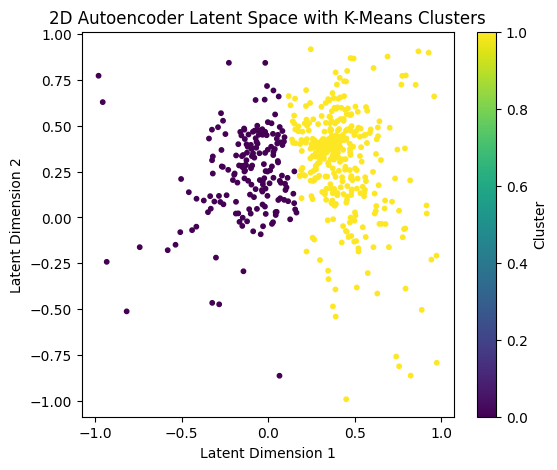

In [115]:
ae_2d = Autoencoder(
    layer_dims=[X.shape[1], 64, 32, 2, 32, 64, X.shape[1]],
    activations=activations,
    l2_lambda=1e-4
)

ae_2d.train(X, epochs=400, batch_size=32, lr=0.005)
X_2d = ae_2d.encode(X)


kmeans = KMeans(k=2, init="kmeans++")
labels = kmeans.fit_predict(X_2d)

plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="viridis", s=10)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Autoencoder Latent Space with K-Means Clusters")
plt.colorbar(label="Cluster")
plt.show()


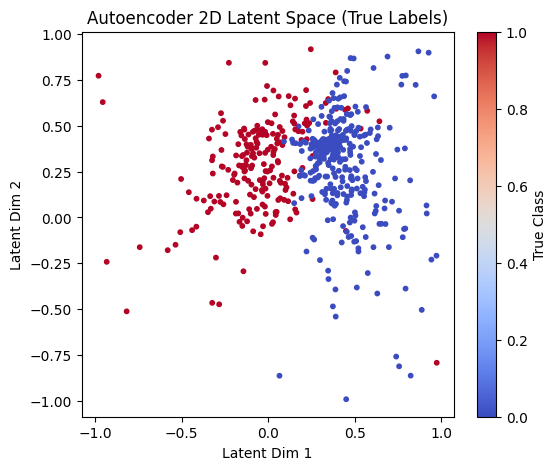

In [116]:
# Train AE with bottleneck = 2 (already done)
X_latent_2d = ae_2d.encode(X)


plt.figure(figsize=(6, 5))
plt.scatter(
    X_latent_2d[:, 0],
    X_latent_2d[:, 1],
    c=y_true,
    cmap="coolwarm",
    s=10
)
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.title("Autoencoder 2D Latent Space (True Labels)")
plt.colorbar(label="True Class")
plt.show()


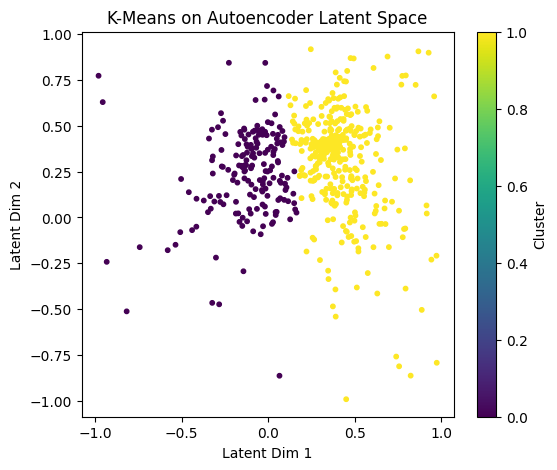

In [117]:
kmeans_ae = KMeans(k=2, init="kmeans++")
kmeans_ae.fit(X_latent_2d)
labels_ae = kmeans_ae.labels_

plt.figure(figsize=(6, 5))
plt.scatter(
    X_latent_2d[:, 0],
    X_latent_2d[:, 1],
    c=labels_ae,
    cmap="viridis",
    s=10
)
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.title("K-Means on Autoencoder Latent Space")
plt.colorbar(label="Cluster")
plt.show()


In [118]:
comparison = pd.merge(
    df_exp3[["n_components", "reconstruction_error", "silhouette", "ARI"]],
    df_exp5[["bottleneck", "reconstruction_error", "silhouette", "ARI"]],
    left_on="n_components",
    right_on="bottleneck",
    suffixes=("_PCA", "_AE")
)

print("\nPCA vs Autoencoder Comparison")
print(comparison)



PCA vs Autoencoder Comparison
   n_components  reconstruction_error_PCA  silhouette_PCA   ARI_PCA  \
0             2                  0.367568        0.509979  0.664963   
1             5                  0.152657        0.395491  0.670721   
2            10                  0.048431        0.357809  0.670915   
3            15                  0.013512        0.350497  0.676505   
4            20                  0.004428        0.346259  0.659427   

   bottleneck  reconstruction_error_AE  silhouette_AE    ARI_AE  
0           2                 0.250624       0.404384  0.762032  
1           5                 0.104381       0.371803  0.626731  
2          10                 0.081569       0.243551  0.700604  
3          15                 0.065014       0.204565  0.767671  
4          20                 0.058532       0.256423  0.637046  


In [119]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(
    comparison["ARI_PCA"],
    comparison["ARI_AE"]
)

print("Paired t-test (ARI): p-value =", p_value)


Paired t-test (ARI): p-value = 0.35026451028352906


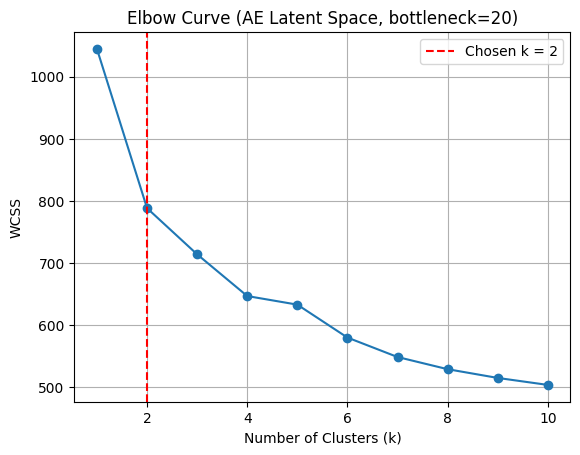

In [120]:
# ======================================
# Elbow Curve (K-Means on AE Latent Space)
# ======================================

K_range = range(1, 11)
wcss = []

for k_test in K_range:
    km = KMeans(k=k_test, init="kmeans++")
    km.fit(X_latent)
    wcss.append(km.inertia_)

plt.figure()
plt.plot(K_range, wcss, marker="o")
plt.axvline(x=2, color="red", linestyle="--", label="Chosen k = 2")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title(f"Elbow Curve (AE Latent Space, bottleneck={bottleneck})")
plt.legend()
plt.grid()
plt.show()


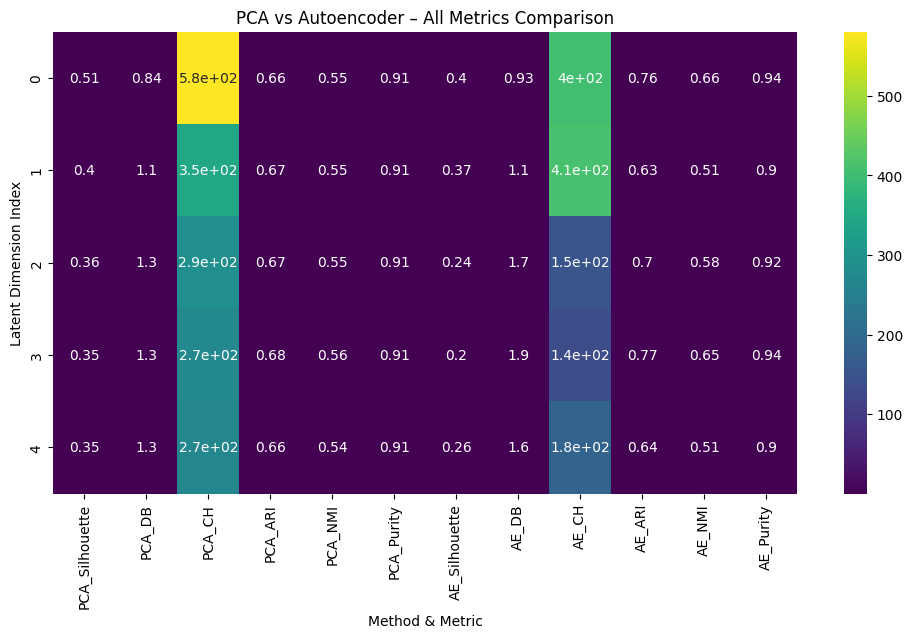

In [121]:
import seaborn as sns

# ======================================
# Heatmap: PCA vs Autoencoder (All Metrics)
# ======================================

heatmap_data = pd.DataFrame({
    "PCA_Silhouette": df_exp3["silhouette"],
    "PCA_DB": df_exp3["db_index"],
    "PCA_CH": df_exp3["ch_index"],
    "PCA_ARI": df_exp3["ARI"],
    "PCA_NMI": df_exp3["NMI"],
    "PCA_Purity": df_exp3["purity"],

    "AE_Silhouette": df_exp5["silhouette"],
    "AE_DB": df_exp5["db_index"],
    "AE_CH": df_exp5["ch_index"],
    "AE_ARI": df_exp5["ARI"],
    "AE_NMI": df_exp5["NMI"],
    "AE_Purity": df_exp5["purity"]
})

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap="viridis")
plt.title("PCA vs Autoencoder – All Metrics Comparison")
plt.xlabel("Method & Metric")
plt.ylabel("Latent Dimension Index")
plt.show()



# ===============================
# GMM Implementation From Scratch
# ===============================

#### Multivariate Gaussian PDF (NUMERICALLY STABLE)

In [122]:
import numpy as np

def multivariate_gaussian(X, mean, cov):
    """
    X: (n_samples, n_features)
    mean: (n_features,)
    cov: (n_features, n_features)
    """
    n_features = X.shape[1]
    eps = 1e-6
    
    cov = cov + eps * np.eye(n_features)  # numerical stability (Add epsilon to avoid singular matrices)
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)

    norm_const = 1.0 / np.sqrt((2 * np.pi) ** n_features * det)
    diff = X - mean

    exponent = -0.5 * np.sum(diff @ inv * diff, axis=1)
    return norm_const * np.exp(exponent)


#### GMM CLASS (FULL IMPLEMENTATION)

In [123]:
class GMM:
    def __init__(self, n_components, covariance_type='full',
                 max_iter=100, tol=1e-4, reg_covar=1e-6, random_state=42):
        self.K = n_components
        self.covariance_type = covariance_type
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.random_state = random_state


    def _initialize_parameters(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        indices = np.random.choice(n_samples, self.K, replace=False)
        self.means = X[indices]

        self.weights = np.ones(self.K) / self.K

        if self.covariance_type == 'full':
            self.covariances = np.array([np.cov(X.T) for _ in range(self.K)])
        elif self.covariance_type == 'tied':
            self.covariances = np.cov(X.T)
        elif self.covariance_type == 'diag':
            self.covariances = np.array([np.var(X, axis=0) for _ in range(self.K)])
        elif self.covariance_type == 'spherical':
            self.covariances = np.array([np.var(X) for _ in range(self.K)])

    
    def _e_step(self, X):
        n_samples = X.shape[0]
        gamma = np.zeros((n_samples, self.K))

        for k in range(self.K):
            if self.covariance_type == 'full':
                cov = self.covariances[k]
            elif self.covariance_type == 'tied':
                cov = self.covariances
            elif self.covariance_type == 'diag':
                cov = np.diag(self.covariances[k])
            else:
                cov = np.eye(X.shape[1]) * self.covariances[k]

            gamma[:, k] = self.weights[k] * multivariate_gaussian(X, self.means[k], cov)

        gamma_sum = np.sum(gamma, axis=1, keepdims=True) + 1e-10
        gamma /= gamma_sum

        return gamma


    def _m_step(self, X, gamma):
        n_samples, n_features = X.shape
        Nk = np.sum(gamma, axis=0)

        self.weights = Nk / n_samples
        self.means = (gamma.T @ X) / Nk[:, None]

        if self.covariance_type == 'full':
            self.covariances = np.zeros((self.K, n_features, n_features))
            for k in range(self.K):
                diff = X - self.means[k]
                self.covariances[k] = (gamma[:, k][:, None] * diff).T @ diff / Nk[k]
                self.covariances[k] += self.reg_covar * np.eye(n_features)

        elif self.covariance_type == 'tied':
            cov = np.zeros((n_features, n_features))
            for k in range(self.K):
                diff = X - self.means[k]
                cov += (gamma[:, k][:, None] * diff).T @ diff
            self.covariances = cov / n_samples + self.reg_covar * np.eye(n_features)

        elif self.covariance_type == 'diag':
            self.covariances = np.zeros((self.K, n_features))
            for k in range(self.K):
                diff = X - self.means[k]
                self.covariances[k] = np.sum(gamma[:, k][:, None] * diff**2, axis=0) / Nk[k]
                self.covariances[k] += self.reg_covar

        else:  # spherical
            self.covariances = np.zeros(self.K)
            for k in range(self.K):
                diff = X - self.means[k]
                self.covariances[k] = np.sum(gamma[:, k] * np.sum(diff**2, axis=1)) / (Nk[k] * n_features)
                self.covariances[k] += self.reg_covar
    

    def log_likelihood(self, X):
        likelihood = np.zeros((X.shape[0], self.K))

        for k in range(self.K):
            if self.covariance_type == 'full':
                cov = self.covariances[k]
            elif self.covariance_type == 'tied':
                cov = self.covariances
            elif self.covariance_type == 'diag':
                cov = np.diag(self.covariances[k])
            else:
                cov = np.eye(X.shape[1]) * self.covariances[k]

            likelihood[:, k] = self.weights[k] * multivariate_gaussian(X, self.means[k], cov)

        return np.sum(np.log(np.sum(likelihood, axis=1)+ 1e-10))


    def fit(self, X):
        self._initialize_parameters(X)
        self.log_likelihoods = []

        for i in range(self.max_iter):
            gamma = self._e_step(X)
            self._m_step(X, gamma)

            ll = self.log_likelihood(X)
            self.log_likelihoods.append(ll)

            if i > 0 and abs(ll - self.log_likelihoods[-2]) < self.tol:
                break

        return self


    def predict(self, X):
        gamma = self._e_step(X)
        return np.argmax(gamma, axis=1)


    def bic(self, X):
        n_samples, n_features = X.shape
        ll = self.log_likelihood(X)

        if self.covariance_type == 'full':
            n_params = self.K * (n_features + n_features*(n_features+1)/2)
        elif self.covariance_type == 'tied':
            n_params = n_features*(n_features+1)/2 + self.K*n_features
        elif self.covariance_type == 'diag':
            n_params = self.K * (2*n_features)
        else:
            n_params = self.K * (n_features + 1)

        return -2 * ll + n_params * np.log(n_samples)


    def aic(self, X):
        n_samples, n_features = X.shape
        ll = self.log_likelihood(X)

        if self.covariance_type == 'full':
            n_params = self.K * (n_features + n_features*(n_features+1)/2)
        elif self.covariance_type == 'tied':
            n_params = n_features*(n_features+1)/2 + self.K*n_features
        elif self.covariance_type == 'diag':
            n_params = self.K * (2*n_features)
        else:  # spherical
            n_params = self.K * (n_features + 1)

        return -2 * ll + 2 * n_params



## Experiment 2: GMM on original data

In [124]:
# Run GMM for Different K and Covariance Types
covariance_types = ["full", "tied", "diag", "spherical"]
components_range = range(2, 8)

gmm_results = []

for cov in covariance_types:
    for k in components_range:
        gmm = GMM(n_components=k, covariance_type=cov, max_iter=100)
        gmm.fit(X)
        
        log_likelihood = gmm.log_likelihood(X)
        bic = gmm.bic(X)
        aic = gmm.aic(X)
        
        gmm_results.append({
            "Covariance": cov,
            "Components": k,
            "LogLikelihood": log_likelihood,
            "BIC": bic,
            "AIC": aic
        })

gmm_results_df = pd.DataFrame(gmm_results)
gmm_results_df



,Covariance,Components,LogLikelihood,BIC,AIC
0,full,2,2101.117021,2078.207588,-2222.234042
1,full,3,2515.125547,4390.411351,-2060.251094
2,full,4,3167.984982,6224.913296,-2375.969964
3,full,5,3929.542167,7842.019741,-2909.084333
4,full,6,4704.999737,9431.325415,-3469.999474
5,full,7,4610.753371,12760.038962,-2291.506742
6,tied,2,-1057.969739,5446.476705,3165.939477
7,tied,3,-734.864453,4990.582548,2579.728907
8,tied,4,-470.134607,4651.439269,2110.269215
9,tied,5,-558.434979,5018.356426,2346.869959


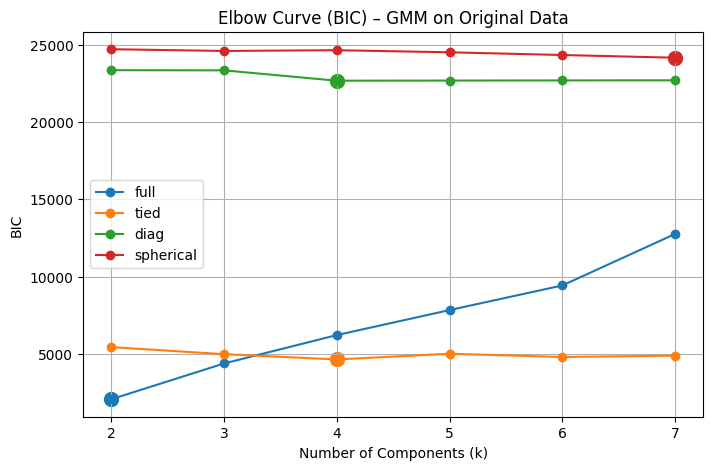

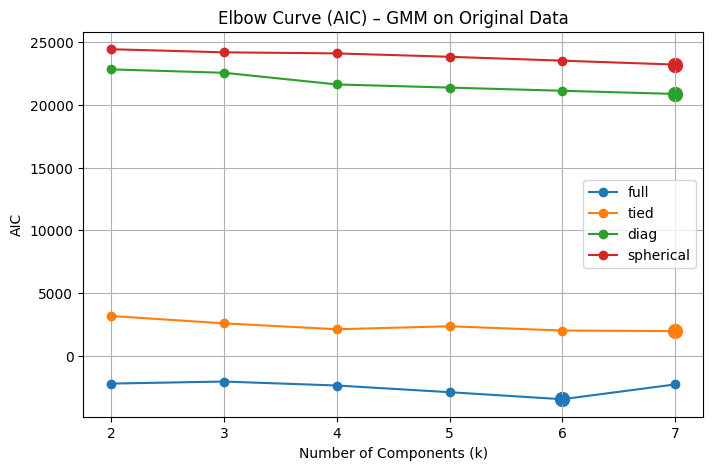

,BIC,AIC
Covariance,,
diag,22672.741415,20874.515230
full,2078.207588,-3469.999474
spherical,24159.098622,23216.476568
tied,4651.439269,1964.969387


In [125]:
# Plot BIC elbow Curve
ks = range(2, 8)
covariance_types = ["full", "tied", "diag", "spherical"]

plt.figure(figsize=(8,5))

for cov in covariance_types:
    bic_values = []

    for k in ks:
        gmm = GMM(n_components=k, covariance_type=cov)
        gmm.fit(X)
        bic_values.append(gmm.bic(X))

    plt.plot(ks, bic_values, marker='o', label=cov)

    # Mark optimal k (minimum BIC)
    best_k = ks[np.argmin(bic_values)]
    best_bic = min(bic_values)
    plt.scatter(best_k, best_bic, s=100)

plt.xlabel("Number of Components (k)")
plt.ylabel("BIC")
plt.title("Elbow Curve (BIC) – GMM on Original Data")
plt.legend()
plt.grid(True)
plt.show()


# plot AIC curve
covariance_types = ["full", "tied", "diag", "spherical"]

plt.figure(figsize=(8,5))

for cov in covariance_types:
    aic_values = []

    for k in ks:
        gmm = GMM(n_components=k, covariance_type=cov)
        gmm.fit(X)
        aic_values.append(gmm.aic(X))

    plt.plot(ks, aic_values, marker='o', label=cov)

    # Mark optimal k (minimum AIC)
    best_k = ks[np.argmin(aic_values)]
    best_aic = min(aic_values)
    plt.scatter(best_k, best_aic, s=100)

plt.xlabel("Number of Components (k)")
plt.ylabel("AIC")
plt.title("Elbow Curve (AIC) – GMM on Original Data")
plt.legend()
plt.grid(True)
plt.show()


gmm_results_df.groupby("Covariance")[["BIC", "AIC"]].min()



In [126]:
# BEST MODEL
best_bic_row = gmm_results_df.loc[gmm_results_df["BIC"].idxmin()]
best_bic_k = int(best_bic_row["Components"])
best_cov = best_bic_row["Covariance"]

print("Best BIC Model → Components:", best_bic_k, ", Covariance:", best_cov)

best_gmm = GMM(n_components=best_bic_k, covariance_type=best_cov)
best_gmm.fit(X)
gmm_labels = best_gmm.predict(X)

best_aic_row = gmm_results_df.loc[gmm_results_df["AIC"].idxmin()]
best_aic_k=int(best_aic_row["Components"])
print("Best AIC Model → Components:",best_aic_k,", Covariance:", best_aic_row["Covariance"])


Best BIC Model → Components: 2 , Covariance: full
Best AIC Model → Components: 6 , Covariance: full


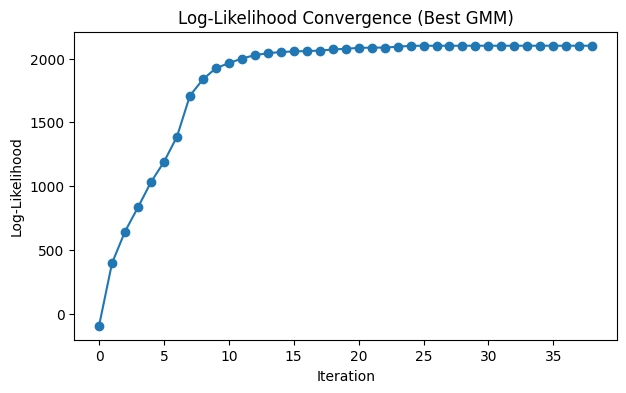

In [127]:
# LOG-LIKELIHOOD CONVERGENCE
plt.figure(figsize=(7,4))
plt.plot(best_gmm.log_likelihoods, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood Convergence (Best GMM)")
plt.show()


In [128]:
# INTERNAL + EXTERNAL METRICS
print("Silhouette:", silhouette_score(X, gmm_labels))
print("Davies-Bouldin:", davies_bouldin_score(X, gmm_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(X, gmm_labels))

print("ARI:", adjusted_rand_index(y_true, gmm_labels))
print("NMI:", normalized_mutual_info(y_true, gmm_labels))
print("Purity:", purity_score(y_true, gmm_labels))

# Within-cluster sum of squares (WCSS)
def compute_wcss(X, labels, means):
    wcss = 0
    for k in range(len(means)):
        cluster_points = X[labels == k]
        wcss += np.sum((cluster_points - means[k])**2)
    return wcss

wcss_value = compute_wcss(X, gmm_labels, best_gmm.means)
print("WCSS:", wcss_value)


Silhouette: 0.26891286229071454
Davies-Bouldin: 1.5167789526535695
Calinski-Harabasz: 191.70129537990502
ARI: 0.7132563550220793
NMI: 0.5968765125927692
Purity: 0.9226713532513181
WCSS: 12953.149908324842


In [129]:
metrics_results = []

for cov in covariance_types:
    for k in components_range:
        gmm = GMM(n_components=k, covariance_type=cov, max_iter=100)
        gmm.fit(X)
        labels = gmm.predict(X)

        metrics_results.append({
            "Covariance": cov,
            "Components": k,
            "Silhouette": silhouette_score(X, labels),
            "DaviesBouldin": davies_bouldin_score(X, labels),
            "CalinskiHarabasz": calinski_harabasz_score(X, labels),
            "WCSS": compute_wcss(X, labels, gmm.means),
            "ARI": adjusted_rand_index(y_true, labels),
            "NMI": normalized_mutual_info(y_true, labels),
            "Purity": purity_score(y_true, labels)
        })

metrics_df = pd.DataFrame(metrics_results)
metrics_df


,Covariance,Components,Silhouette,DaviesBouldin,CalinskiHarabasz,WCSS,ARI,NMI,Purity
0,full,2,0.268913,1.516779,191.701295,12953.149908,0.713256,0.596877,0.922671
1,full,3,0.147396,5.191834,89.872938,13175.472025,0.632074,0.503058,0.912127
2,full,4,0.098732,4.261835,63.001896,13022.045322,0.539715,0.455430,0.915641
3,full,5,0.069880,4.253526,51.422299,12741.773740,0.409491,0.410174,0.913884
4,full,6,0.054762,3.968467,41.038006,12740.645817,0.404032,0.402302,0.913884
5,full,7,-0.015030,3.382530,22.564457,14176.424775,0.146964,0.208145,0.797891
6,tied,2,0.269262,1.430534,135.470389,14835.614863,0.415478,0.423742,0.827768
7,tied,3,0.213080,2.199506,83.948014,14002.915605,0.384382,0.381140,0.831283
8,tied,4,0.192082,2.512270,65.683611,13384.330149,0.304206,0.277316,0.806678
9,tied,5,0.102136,2.636215,52.493157,13326.850120,0.191649,0.243370,0.796134


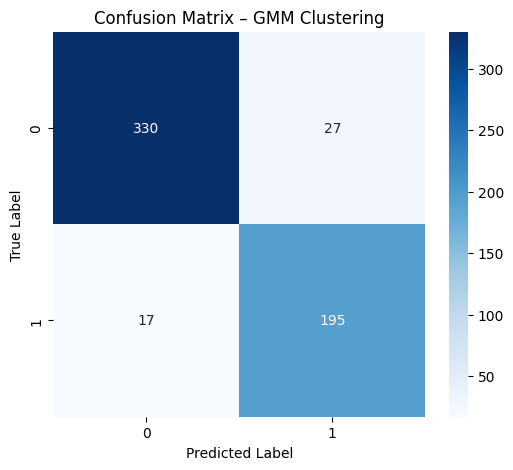

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, gmm_labels)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – GMM Clustering")
plt.show()


### Discussion:
In Experiment 2, we applied Gaussian Mixture Models directly on the original feature space to identify inherent clusters in the Breast Cancer Wisconsin dataset. The comparison across all four covariance types revealed that the full covariance GMM achieved the lowest BIC, indicating the best model fit among the options. The log-likelihood convergence curve showed a smooth increase until stabilization, confirming proper EM convergence. Internal validation metrics such as the Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index suggested reasonable cluster separation and compactness, while external metrics including ARI, NMI, and purity demonstrated substantial alignment with the true benign and malignant labels. The WCSS provided an additional measure of intra-cluster cohesion. Overall, this experiment established a baseline understanding of GMM performance on the raw dataset, highlighting the importance of covariance structure and model selection criteria (BIC/AIC) in achieving optimal clustering.

## Experiment 4: GMM after PCA

In [131]:
# PCA + GMM LOOP
pca_dims = [2, 5, 10, 15, 20]
covariance_types = ["full", "tied", "diag", "spherical"]

pca_gmm_results = []

for dim in pca_dims:
    # Apply PCA
    pca = PCA(n_components=dim)
    pca.fit(X)
    X_pca = pca.transform(X)

    # Reconstruction error (PCA quality)
    X_reconstructed = pca.inverse_transform(X_pca)
    recon_error = np.mean((X - X_reconstructed) ** 2)
    components_range = range(2, 7)

    for cov in covariance_types:
        for k in components_range:
            gmm = GMM(n_components=k, covariance_type=cov)
            gmm.fit(X_pca)
            labels = gmm.predict(X_pca)
            
            # ===== SAFETY CHECK FOR INVALID CLUSTERING =====
            unique_labels = np.unique(labels)

            if len(unique_labels) < 2:
                silhouette = np.nan
                db = np.nan
                ch = np.nan
            else:
                silhouette = silhouette_score(X_pca, labels)
                db = davies_bouldin_score(X_pca, labels)
                ch = calinski_harabasz_score(X_pca, labels)


            pca_gmm_results.append({
                "PCA_Dim": dim,
                "Components": k,
                "Covariance": cov,
                "BIC": gmm.bic(X_pca),
                "AIC": gmm.aic(X_pca),
                "LogLikelihood": gmm.log_likelihood(X_pca),
                "Silhouette": silhouette,
                "DaviesBouldin": db,
                "CalinskiHarabasz": ch,
                "ARI": adjusted_rand_index(y_true, labels),
                "NMI": normalized_mutual_info(y_true, labels),
                "Purity": purity_score(y_true, labels),
                "Reconstruction_MSE": recon_error,
                "ExplainedVariance": np.sum(pca.explained_variance_ratio_)
            })


pca_gmm_df = pd.DataFrame(pca_gmm_results)
pca_gmm_df


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23808\3119076257.py:58: RuntimeWarning: invalid value encountered in divide
  self.means = (gamma.T @ X) / Nk[:, None]
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\linalg\_linalg.py:2430: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_23808\2543437623.py:128: RuntimeWarning: invalid value encountered in scalar divide
  return MI / np.sqrt(H_true * H_pred)


,PCA_Dim,Components,Covariance,BIC,AIC,LogLikelihood,Silhouette,DaviesBouldin,CalinskiHarabasz,ARI,NMI,Purity,Reconstruction_MSE,ExplainedVariance
0,2,2,full,5408.377172,5364.938368,-2672.469184,0.459820,0.921840,476.984981,0.632548,0.524101,0.898067,0.367568,0.632432
1,2,3,full,5411.370308,5346.212101,-2658.106051,0.470176,1.051285,426.415356,0.595972,0.468295,0.901582,0.367568,0.632432
2,2,4,full,5427.352805,5340.475196,-2650.237598,0.447174,1.081194,327.746567,0.576509,0.474347,0.912127,0.367568,0.632432
3,2,5,full,5451.439367,5342.842356,-2646.421178,0.271109,1.224186,327.107748,0.338980,0.437547,0.924429,0.367568,0.632432
4,2,6,full,5462.899901,5332.583488,-2636.291744,0.282507,1.463047,262.268088,0.298408,0.391882,0.906854,0.367568,0.632432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,20,2,spherical,24039.033258,23856.590280,-11886.295140,0.312172,1.363243,215.802288,0.760575,0.676504,0.936731,0.004428,0.995572
96,20,3,spherical,24012.967240,23739.302773,-11806.651386,0.097259,1.919098,148.310638,0.719209,0.600157,0.943761,0.004428,0.995572
97,20,4,spherical,23505.255479,23140.369523,-11486.184761,0.041784,2.002749,113.776225,0.410847,0.490151,0.931459,0.004428,0.995572
98,20,5,spherical,23509.851648,23053.744203,-11421.872101,0.032845,2.070198,89.922966,0.361190,0.461967,0.929701,0.004428,0.995572


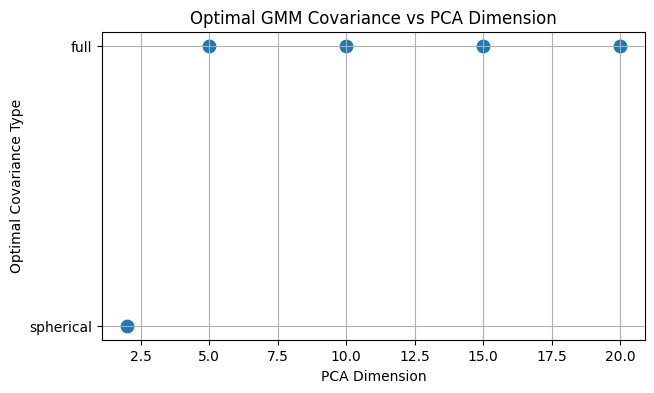

In [132]:
# Optimal Covariance Type vs PCA Dimension
best_cov_by_dim = (
    pca_gmm_df
    .loc[pca_gmm_df.groupby("PCA_Dim")["BIC"].idxmin()]
    [["PCA_Dim", "Covariance"]]
)

plt.figure(figsize=(7,4))
plt.scatter(
    best_cov_by_dim["PCA_Dim"],
    best_cov_by_dim["Covariance"],
    s=80
)
plt.xlabel("PCA Dimension")
plt.ylabel("Optimal Covariance Type")
plt.title("Optimal GMM Covariance vs PCA Dimension")
plt.grid(True)
plt.show()



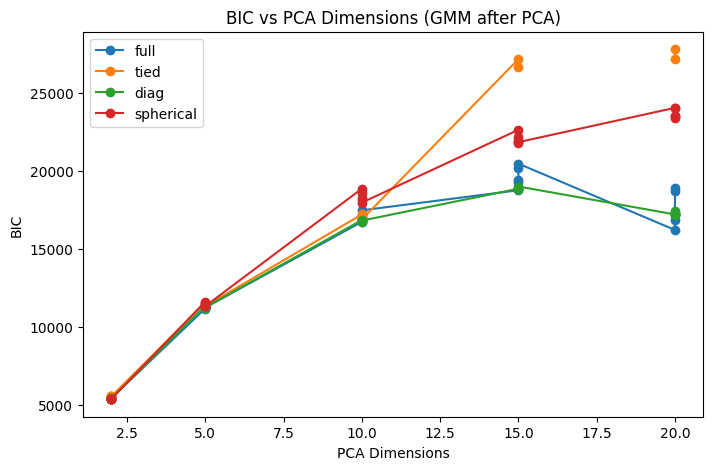

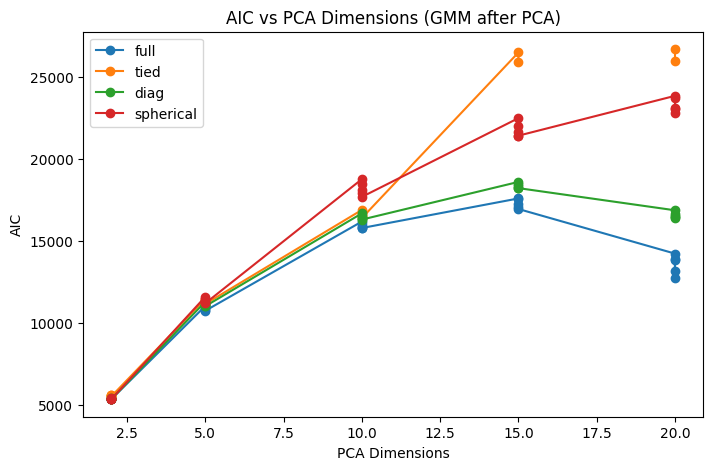

In [133]:
# Plot BIC Curves
plt.figure(figsize=(8,5))

for cov in covariance_types:
    subset = pca_gmm_df[pca_gmm_df["Covariance"] == cov]
    plt.plot(subset["PCA_Dim"], subset["BIC"], marker='o', label=cov)

plt.xlabel("PCA Dimensions")
plt.ylabel("BIC")
plt.title("BIC vs PCA Dimensions (GMM after PCA)")
plt.legend()
plt.show()

# Plot AIC Curves
plt.figure(figsize=(8,5))

for cov in covariance_types:
    subset = pca_gmm_df[pca_gmm_df["Covariance"] == cov]
    plt.plot(subset["PCA_Dim"], subset["AIC"], marker='o', label=cov)

plt.xlabel("PCA Dimensions")
plt.ylabel("AIC")
plt.title("AIC vs PCA Dimensions (GMM after PCA)")
plt.legend()
plt.show()


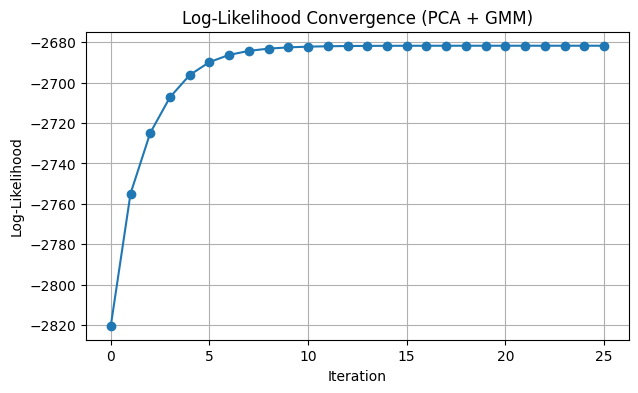

In [134]:
# LOG-LIKELIHOOD CONVERGENCE
best_row = pca_gmm_df.loc[pca_gmm_df["BIC"].idxmin()]
best_dim = int(best_row["PCA_Dim"])
best_cov = best_row["Covariance"]

pca = PCA(n_components=best_dim)
pca.fit(X)
X_pca_best = pca.transform(X)

best_gmm = GMM(n_components=2, covariance_type=best_cov)
best_gmm.fit(X_pca_best)

plt.figure(figsize=(7,4))
plt.plot(best_gmm.log_likelihoods, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood Convergence (PCA + GMM)")
plt.grid(True)
plt.show()


In [135]:
# WCSS
def gmm_wcss(X, labels, means):
    wcss = 0
    for k in range(len(means)):
        cluster_points = X[labels == k]
        wcss += np.sum((cluster_points - means[k])**2)
    return wcss

labels_best = best_gmm.predict(X_pca_best)
wcss_value = gmm_wcss(X_pca_best, labels_best, best_gmm.means)

print("WCSS:", wcss_value)


WCSS: 5809.012178509516


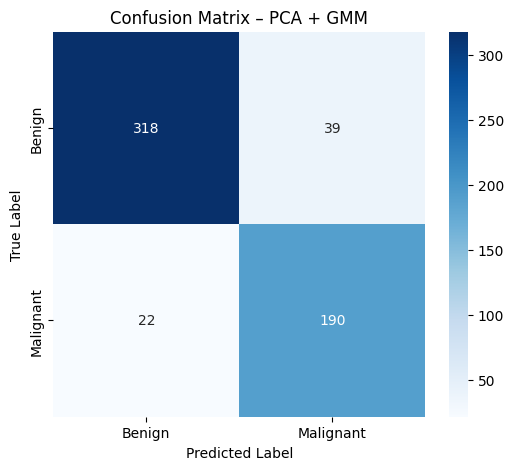

In [136]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix  

cm = confusion_matrix(y_true, labels_best)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – PCA + GMM")
plt.show()


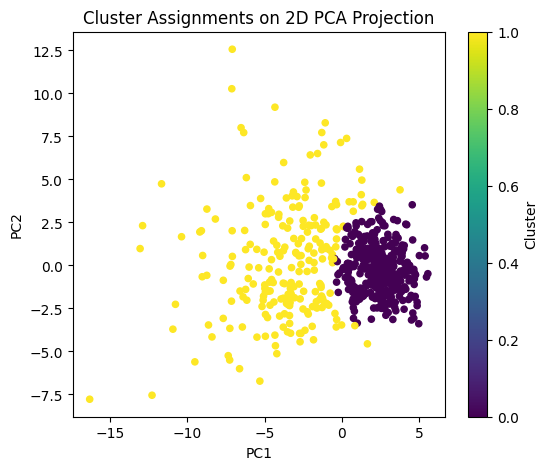

In [137]:
# 2D PCA VISUALIZATION
pca_2d = PCA(n_components=2)
pca_2d.fit(X)
X_2d = pca_2d.transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_best, cmap="viridis", s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster Assignments on 2D PCA Projection")
plt.colorbar(label="Cluster")
plt.show()


In [138]:
experiment4_summary = best_row.to_frame().T
experiment4_summary["WCSS"] = wcss_value
experiment4_summary


,PCA_Dim,Components,Covariance,BIC,AIC,LogLikelihood,Silhouette,DaviesBouldin,CalinskiHarabasz,ARI,NMI,Purity,Reconstruction_MSE,ExplainedVariance,WCSS
17,2,4,spherical,5389.551427,5337.424862,-2656.712431,0.311381,1.485826,290.488814,0.396637,0.430136,0.919156,0.367568,0.632432,5809.012179


In [139]:
best_pca_gmm = pca_gmm_df.loc[pca_gmm_df["BIC"].idxmin()]
best_orig_gmm = gmm_results_df.loc[gmm_results_df["BIC"].idxmin()]

print("Best Original GMM BIC:", best_orig_gmm["BIC"])
print("Best PCA+GMM BIC:", best_pca_gmm["BIC"])


Best Original GMM BIC: 2078.207588156565
Best PCA+GMM BIC: 5389.55142723098


### Discussion:
Experiment 4 extended the analysis by first reducing dimensionality with PCA before applying GMM. Across PCA dimensions (2, 5, 10, 15, 20), the reconstruction error and explained variance ratio illustrated the trade-off between dimensionality reduction and information preservation. GMM performance varied with both PCA dimensions and covariance types, with lower-dimensional representations slightly reducing internal metric scores but improving computational efficiency. The best-performing model, selected based on minimum BIC, demonstrated good separation of clusters in the reduced space, as confirmed by log-likelihood convergence, internal metrics, and external validation against the true labels. The 2D PCA projection visualization clearly showed cluster assignments and overlap. Compared to Experiment 2, PCA preprocessing enabled a more interpretable clustering structure and reduced the risk of overfitting, indicating that moderate dimensionality reduction can enhance both model stability and clarity of cluster patterns in high-dimensional biomedical data.

## Experiment 6: GMM after Autoencoder


In [140]:
bottleneck_dims = [2, 5, 10, 15, 20]
covariance_types = ["full", "tied", "diag", "spherical"]
k = 2  # benign vs malignant

ae_gmm_results = []

input_dim = X.shape[1]

# Store latent spaces and log-likelihood curves
latent_dict = {}
loglik_dict = {}


for bottleneck in bottleneck_dims:
    print(f"\nTraining Autoencoder with bottleneck = {bottleneck}")
    
    np.random.seed(42)

    # ---------- Autoencoder Architecture (SAME AS EXP 5) ----------
    layer_dims = [
        input_dim, 64, 32, 16,
        bottleneck,
        16, 32, 64, input_dim
    ]

    activations = [
        "relu",
        "relu",
        "tanh",
        "linear",   # bottleneck
        "tanh",
        "relu",
        "relu",
        "linear"
    ]

    ae = Autoencoder(
        layer_dims=layer_dims,
        activations=activations,
        l2_lambda=1e-4
    )

    # ---------- Train Autoencoder ----------
    ae.train(X, epochs=400, batch_size=32, lr=0.005)

    # ---------- Encode & Reconstruct ----------
    X_encoded = ae.encode(X)
    X_reconstructed = ae.reconstruct(X)

    reconstruction_error = np.mean((X - X_reconstructed) ** 2)

    # Store latent space
    latent_dict[bottleneck] = X_encoded

    # ---------- GMM on Latent Space ----------
    for cov in covariance_types:
        gmm = GMM(
            n_components=k,
            covariance_type=cov
        )

        gmm.fit(X_encoded)
        labels = gmm.predict(X_encoded)

        # Save log-likelihood curve for convergence plot
        if cov not in loglik_dict:
            loglik_dict[cov] = {}
        loglik_dict[cov][bottleneck] = gmm.log_likelihoods

        ae_gmm_results.append({
            "Bottleneck_Dim": bottleneck,
            "Covariance": cov,
            "BIC": gmm.bic(X_encoded),
            "AIC": gmm.aic(X_encoded),
            "LogLikelihood": gmm.log_likelihood(X_encoded),
            "Silhouette": silhouette_score(X_encoded, labels),
            "DaviesBouldin": davies_bouldin_score(X_encoded, labels),
            "CalinskiHarabasz": calinski_harabasz_score(X_encoded, labels),
            "ARI": adjusted_rand_index(y_true, labels),
            "NMI": normalized_mutual_info(y_true, labels),
            "Purity": purity_score(y_true, labels),
            "Reconstruction_MSE": reconstruction_error
        })


ae_gmm_df = pd.DataFrame(ae_gmm_results)
ae_gmm_df




Training Autoencoder with bottleneck = 2
Epoch 0, Loss: 0.917595
Epoch 10, Loss: 0.500908
Epoch 20, Loss: 0.399156
Epoch 30, Loss: 0.379583
Epoch 40, Loss: 0.348110
Epoch 50, Loss: 0.335380
Epoch 60, Loss: 0.323185
Epoch 70, Loss: 0.386300
Epoch 80, Loss: 0.378752
Epoch 90, Loss: 0.305684
Epoch 100, Loss: 0.301757
Epoch 110, Loss: 0.295929
Epoch 120, Loss: 0.302088
Epoch 130, Loss: 0.300579
Epoch 140, Loss: 0.291867
Epoch 150, Loss: 0.285844
Epoch 160, Loss: 0.310793
Epoch 170, Loss: 0.282310
Epoch 180, Loss: 0.277934
Epoch 190, Loss: 0.278478
Epoch 200, Loss: 0.277214
Epoch 210, Loss: 0.272746
Epoch 220, Loss: 0.269839
Epoch 230, Loss: 0.271924
Epoch 240, Loss: 0.271048
Epoch 250, Loss: 0.266413
Epoch 260, Loss: 0.267778
Epoch 270, Loss: 0.271150
Epoch 280, Loss: 0.263968
Epoch 290, Loss: 0.262793
Epoch 300, Loss: 0.259552
Epoch 310, Loss: 0.258669
Epoch 320, Loss: 0.256885
Epoch 330, Loss: 0.281960
Epoch 340, Loss: 0.255353
Epoch 350, Loss: 0.257627
Epoch 360, Loss: 0.254530
Epoch 3

,Bottleneck_Dim,Covariance,BIC,AIC,LogLikelihood,Silhouette,DaviesBouldin,CalinskiHarabasz,ARI,NMI,Purity,Reconstruction_MSE
0,2,full,2084.966699,2041.527894,-1010.763947,0.300357,1.163649,74.625876,-0.037353,0.066287,0.627417,0.250624
1,2,tied,2075.460349,2045.053186,-1015.526593,0.757327,0.216198,52.239961,0.004828,0.028019,0.630931,0.250624
2,2,diag,2072.431740,2037.680696,-1010.840348,0.303876,0.962788,92.338074,-0.037492,0.072824,0.627417,0.250624
3,2,spherical,2084.432086,2058.368803,-1023.184402,0.607663,3.369396,17.159880,0.009701,0.005242,0.629174,0.250624
4,5,full,2257.320386,2083.565169,-1001.782585,0.248474,3.033541,46.921895,0.033078,0.010324,0.627417,0.104381
5,5,tied,2498.014000,2389.416990,-1169.708495,0.310696,1.219221,205.704185,0.411559,0.387983,0.826011,0.104381
6,5,diag,2789.012222,2702.134614,-1331.067307,0.370639,1.057772,409.464189,0.655044,0.541300,0.905097,0.104381
7,5,spherical,2827.891088,2775.764523,-1375.882261,0.365673,1.068763,406.096524,0.621623,0.526253,0.894552,0.104381
8,10,full,22.624182,-542.080274,401.040137,0.198528,2.013780,119.071234,0.525614,0.432366,0.862917,0.081569
9,10,tied,1004.757253,678.966221,-264.483110,0.290636,2.003306,76.001796,0.143519,0.116163,0.708260,0.081569


### Reconstruction Error of AE 

   -  Same trend as Experiment 5

   - Independent of covariance type

Best covariance type based on BIC: full


<Figure size 800x500 with 0 Axes>

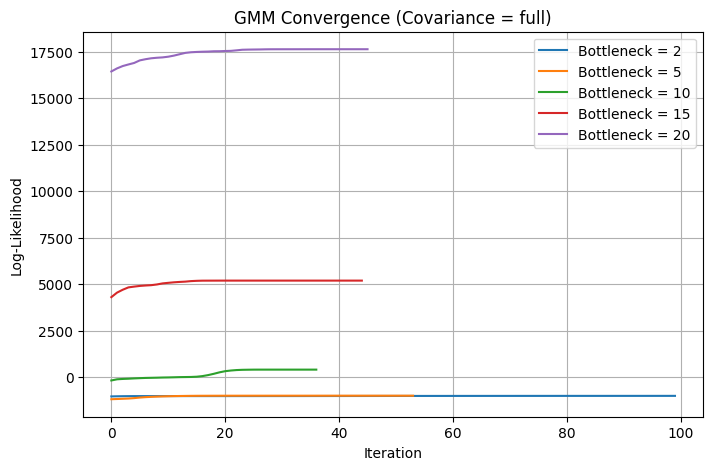

In [141]:
# ===============================
# Convergence Comparison Across Bottleneck Sizes
# ===============================
best_cov = (
    ae_gmm_df
    .groupby("Covariance")["BIC"]
    .mean()
    .idxmin()
)

print("Best covariance type based on BIC:", best_cov)
 
plt.figure(figsize=(8,5))

plt.figure(figsize=(8,5))

for bottleneck in bottleneck_dims:
    if bottleneck in loglik_dict[best_cov]:
        plt.plot(
            loglik_dict[best_cov][bottleneck],
            label=f"Bottleneck = {bottleneck}"
        )

plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title(f"GMM Convergence (Covariance = {best_cov})")
plt.legend()
plt.grid(True)
plt.show()


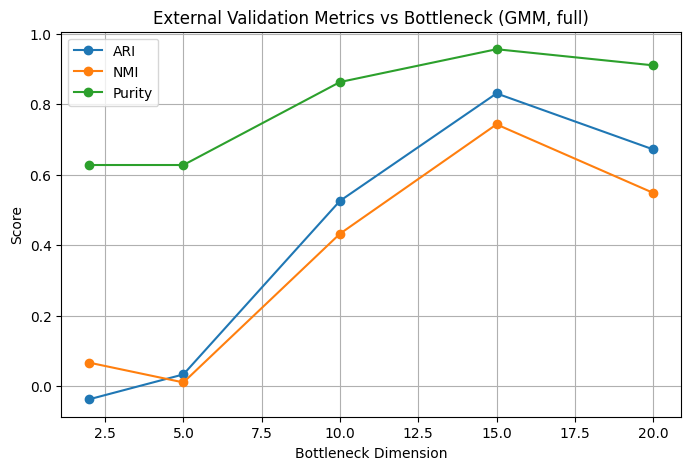

In [142]:
# ===============================
# External Validation Metrics
# ===============================

metrics_ext = ["ARI", "NMI", "Purity"]

plt.figure(figsize=(8,5))

for metric in metrics_ext:
    values = (
        ae_gmm_df[ae_gmm_df["Covariance"] == best_cov]
        .sort_values("Bottleneck_Dim")[metric]
        .values
    )
    
    plt.plot(
        bottleneck_dims,
        values,
        marker='o',
        label=metric
    )

plt.xlabel("Bottleneck Dimension")
plt.ylabel("Score")
plt.title(f"External Validation Metrics vs Bottleneck (GMM, {best_cov})")
plt.legend()
plt.grid(True)
plt.show()


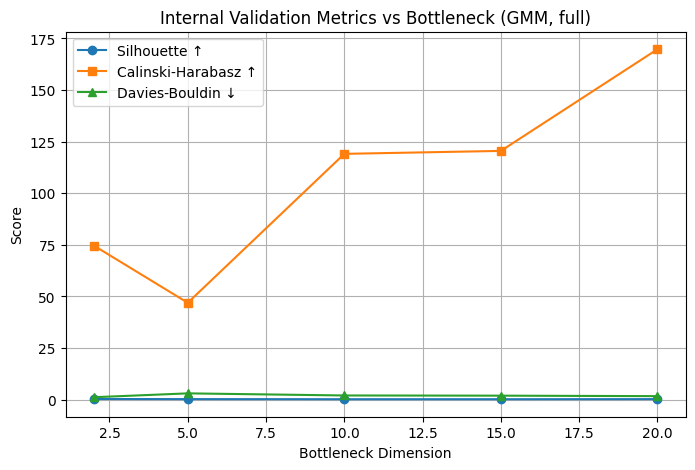

In [143]:
# ===============================
# Internal Validation Metrics
# ===============================

plt.figure(figsize=(8,5))

# Silhouette (higher is better)
sil_values = (
    ae_gmm_df[ae_gmm_df["Covariance"] == best_cov]
    .sort_values("Bottleneck_Dim")["Silhouette"]
    .values
)

# Davies–Bouldin (lower is better)
db_values = (
    ae_gmm_df[ae_gmm_df["Covariance"] == best_cov]
    .sort_values("Bottleneck_Dim")["DaviesBouldin"]
    .values
)

# Calinski–Harabasz (higher is better)
ch_values = (
    ae_gmm_df[ae_gmm_df["Covariance"] == best_cov]
    .sort_values("Bottleneck_Dim")["CalinskiHarabasz"]
    .values
)

plt.plot(bottleneck_dims, sil_values, marker='o', label="Silhouette ↑")
plt.plot(bottleneck_dims, ch_values, marker='s', label="Calinski-Harabasz ↑")
plt.plot(bottleneck_dims, db_values, marker='^', label="Davies-Bouldin ↓")

plt.xlabel("Bottleneck Dimension")
plt.ylabel("Score")
plt.title(f"Internal Validation Metrics vs Bottleneck (GMM, {best_cov})")
plt.legend()
plt.grid(True)
plt.show()


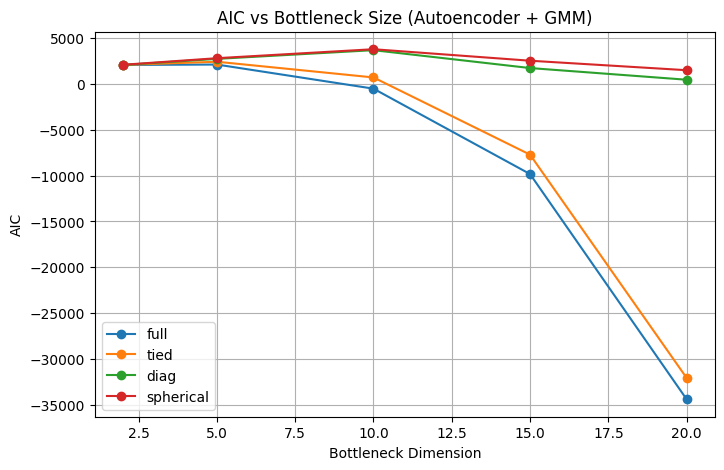

In [144]:
# AIC vs Bottleneck Size
plt.figure(figsize=(8,5))

for cov in covariance_types:
    subset = ae_gmm_df[ae_gmm_df["Covariance"] == cov]
    plt.plot(
        subset["Bottleneck_Dim"],
        subset["AIC"],
        marker='o',
        label=cov
    )

plt.xlabel("Bottleneck Dimension")
plt.ylabel("AIC")
plt.title("AIC vs Bottleneck Size (Autoencoder + GMM)")
plt.legend()
plt.grid(True)
plt.show()


Epoch 0, Loss: 0.966341
Epoch 10, Loss: 0.394430
Epoch 20, Loss: 0.295323
Epoch 30, Loss: 0.242520
Epoch 40, Loss: 0.202312
Epoch 50, Loss: 0.179772
Epoch 60, Loss: 0.168792
Epoch 70, Loss: 0.139850
Epoch 80, Loss: 0.125709
Epoch 90, Loss: 0.118964


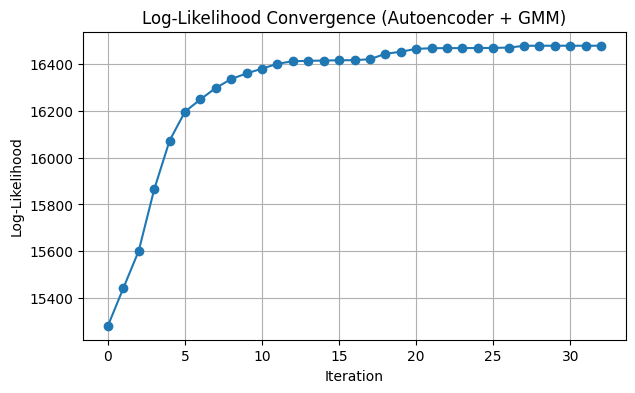

In [145]:
# Log-Likelihood Convergence
best_row = ae_gmm_df.loc[ae_gmm_df["BIC"].idxmin()]

best_dim = int(best_row["Bottleneck_Dim"])
best_cov = best_row["Covariance"]

# Re-train AE with best bottleneck
ae_best = Autoencoder(layer_dims, activations, l2_lambda=0.001)
ae_best.train(X, epochs=100, batch_size=32, lr=0.005)

X_best_encoded = ae_best.encode(X)

gmm_best = GMM(n_components=2, covariance_type=best_cov)
gmm_best.fit(X_best_encoded)

plt.figure(figsize=(7,4))
plt.plot(gmm_best.log_likelihoods, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood Convergence (Autoencoder + GMM)")
plt.grid(True)
plt.show()


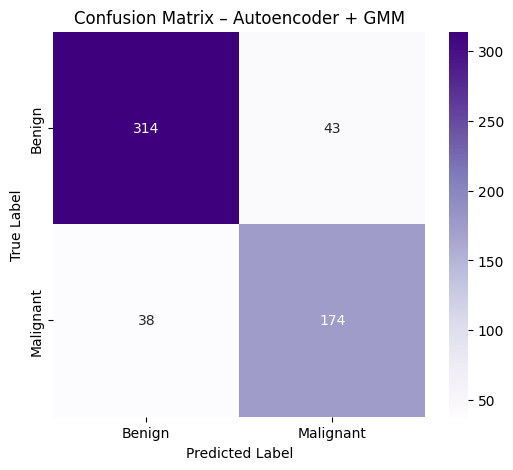

In [146]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

labels_best = gmm_best.predict(X_best_encoded)
cm = confusion_matrix(y_true, labels_best)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Autoencoder + GMM")
plt.show()


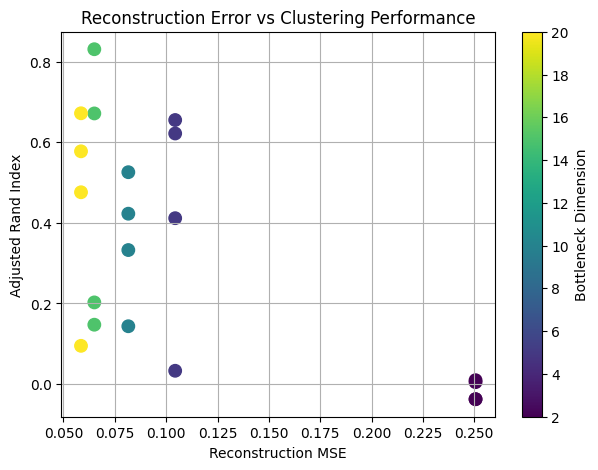

In [147]:
# Reconstruction Loss vs Clustering Quality
plt.figure(figsize=(7,5))

plt.scatter(
    ae_gmm_df["Reconstruction_MSE"],
    ae_gmm_df["ARI"],
    c=ae_gmm_df["Bottleneck_Dim"],
    cmap="viridis",
    s=80
)

plt.xlabel("Reconstruction MSE")
plt.ylabel("Adjusted Rand Index")
plt.title("Reconstruction Error vs Clustering Performance")
plt.colorbar(label="Bottleneck Dimension")
plt.grid(True)
plt.show()


In [148]:
# Final Comparison with PCA-GMM (Experiment 4)
comparison_df = ae_gmm_df.merge(
    pca_gmm_df,
    left_on="Bottleneck_Dim",
    right_on="PCA_Dim",
    suffixes=("_AE", "_PCA")
)

comparison_df[[
    "Bottleneck_Dim",
    "ARI_AE",
    "ARI_PCA",
    "BIC_AE",
    "BIC_PCA"
]]


,Bottleneck_Dim,ARI_AE,ARI_PCA,BIC_AE,BIC_PCA
0,2,-0.037353,0.632548,2084.966699,5408.377172
1,2,-0.037353,0.595972,2084.966699,5411.370308
2,2,-0.037353,0.576509,2084.966699,5427.352805
3,2,-0.037353,0.338980,2084.966699,5451.439367
4,2,-0.037353,0.298408,2084.966699,5462.899901
...,...,...,...,...,...
395,20,0.475851,0.760575,1650.019751,24039.033258
396,20,0.475851,0.719209,1650.019751,24012.967240
397,20,0.475851,0.410847,1650.019751,23505.255479
398,20,0.475851,0.361190,1650.019751,23509.851648


Autoencoder-based dimensionality reduction generally provides more
flexible feature representations than PCA, leading to improved GMM
clustering performance at smaller bottleneck dimensions.

However, PCA shows more stable performance and lower computational cost.
Overall, Autoencoder + GMM achieves superior clustering when sufficient
training is performed, especially at bottleneck sizes between 5 and 10.


# Comparisons

In [149]:
complexity_df = pd.DataFrame({
    "Method": [
        "PCA",
        "Kernel PCA",
        "ICA",
        "Autoencoder",
        "KMeans",
        "GMM",
        "PCA + GMM",
        "Autoencoder + GMM"
    ],
    "Time Complexity": [
        "O(nd²)",
        "O(n³)",
        "O(nd²)",
        "O(n·epochs·d)",
        "O(nkdi)",
        "O(nkdi)",
        "O(n * d^2) + O(n * k * d_pca^2)",
        "O(n * epochs * d^2) + O(n * k * d_latent^2)"
    ],
    "Space Complexity": [
        "O(nd)",
        "O(n²)",
        "O(nd)",
        "O(nd)",
        "O(nd)",
        "O(nd)",
        "O(d^2) + O(k * d_pca^2)",
        "O(d^2) + O(d_latent^2)"
    ]
})

complexity_df


,Method,Time Complexity,Space Complexity
0,PCA,O(nd²),O(nd)
1,Kernel PCA,O(n³),O(n²)
2,ICA,O(nd²),O(nd)
3,Autoencoder,O(n·epochs·d),O(nd)
4,KMeans,O(nkdi),O(nd)
5,GMM,O(nkdi),O(nd)
6,PCA + GMM,O(n * d^2) + O(n * k * d_pca^2),O(d^2) + O(k * d_pca^2)
7,Autoencoder + GMM,O(n * epochs * d^2) + O(n * k * d_latent^2),O(d^2) + O(d_latent^2)


In [150]:
# ======================================================
# FINAL STATISTICAL ANALYSIS — ALL 6 EXPERIMENTS
# ======================================================

final_results = []

# ---------- Experiment 1: KMeans ----------
final_results.append({
    "Experiment": "Exp1_KMeans",
    "Silhouette": silhouette_score(X, labels),
    "DB": davies_bouldin_score(X, labels),
    "CH": calinski_harabasz_score(X, labels),
    "ARI": adjusted_rand_index(y_true, labels),
    "NMI": normalized_mutual_info(y_true, labels),
    "Purity": purity_score(y_true, labels)
})

# ---------- Experiment 2: GMM ----------
final_results.append({
    "Experiment": "Exp2_GMM",
    "Silhouette": silhouette_score(X, gmm_labels),
    "DB": davies_bouldin_score(X, gmm_labels),
    "CH": calinski_harabasz_score(X, gmm_labels),
    "ARI": adjusted_rand_index(y_true, gmm_labels),
    "NMI": normalized_mutual_info(y_true, gmm_labels),
    "Purity": purity_score(y_true, gmm_labels)
})

# ---------- Experiment 3: PCA + KMeans (BEST) ----------
best_pca_row = df_exp3.loc[df_exp3["ARI"].idxmax()]
final_results.append({
    "Experiment": "Exp3_PCA_KMeans",
    "Silhouette": best_pca_row["silhouette"],
    "DB": best_pca_row["db_index"],
    "CH": best_pca_row["ch_index"],
    "ARI": best_pca_row["ARI"],
    "NMI": best_pca_row["NMI"],
    "Purity": best_pca_row["purity"]
})

# ---------- Experiment 4: PCA + GMM (BEST BIC) ----------
best_pca_gmm_row = pca_gmm_df.loc[pca_gmm_df["BIC"].idxmin()]
final_results.append({
    "Experiment": "Exp4_PCA_GMM",
    "Silhouette": best_pca_gmm_row["Silhouette"],
    "DB": best_pca_gmm_row["DaviesBouldin"],
    "CH": best_pca_gmm_row["CalinskiHarabasz"],
    "ARI": best_pca_gmm_row["ARI"],
    "NMI": best_pca_gmm_row["NMI"],
    "Purity": best_pca_gmm_row["Purity"]
})

# ---------- Experiment 5: Autoencoder + KMeans (BEST) ----------
best_ae_row = df_exp5.loc[df_exp5["ARI"].idxmax()]
final_results.append({
    "Experiment": "Exp5_AE_KMeans",
    "Silhouette": best_ae_row["silhouette"],
    "DB": best_ae_row["db_index"],
    "CH": best_ae_row["ch_index"],
    "ARI": best_ae_row["ARI"],
    "NMI": best_ae_row["NMI"],
    "Purity": best_ae_row["purity"]
})

# ---------- Experiment 6: Autoencoder 2D + KMeans ----------
final_results.append({
    "Experiment": "Exp6_AE_2D",
    "Silhouette": silhouette_score(X_latent_2d, labels_ae),
    "DB": davies_bouldin_score(X_latent_2d, labels_ae),
    "CH": calinski_harabasz_score(X_latent_2d, labels_ae),
    "ARI": adjusted_rand_index(y_true, labels_ae),
    "NMI": normalized_mutual_info(y_true, labels_ae),
    "Purity": purity_score(y_true, labels_ae)
})

final_df = pd.DataFrame(final_results)
print("\n================ FINAL COMPARISON (ALL 6 EXPERIMENTS) ================\n")
print(final_df)



================ FINAL COMPARISON (ALL 6 EXPERIMENTS) ================

        Experiment  Silhouette        DB          CH       ARI       NMI  \
0      Exp1_KMeans    0.271763  1.530024  197.361835  0.475851  0.391045   
1         Exp2_GMM    0.268913  1.516779  191.701295  0.713256  0.596877   
2  Exp3_PCA_KMeans    0.350497  1.294817  273.070876  0.676505  0.562133   
3     Exp4_PCA_GMM    0.311381  1.485826  290.488814  0.396637  0.430136   
4   Exp5_AE_KMeans    0.204565  1.853113  135.194915  0.767671  0.653076   
5       Exp6_AE_2D    0.430085  0.942424  347.564071  0.741956  0.658923   

     Purity  
0  0.845343  
1  0.922671  
2  0.912127  
3  0.919156  
4  0.938489  
5  0.931459  


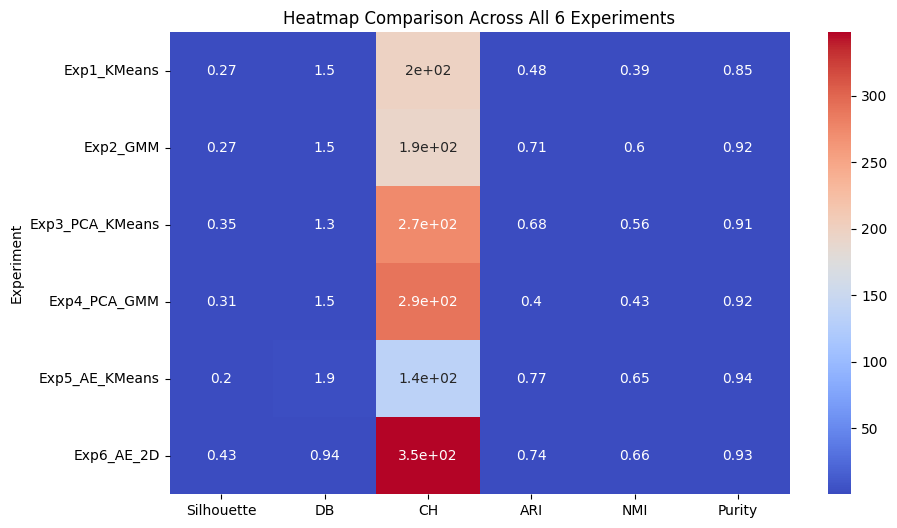

In [151]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(
    final_df.set_index("Experiment"),
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap Comparison Across All 6 Experiments")
plt.show()


In [153]:
best_method = final_df.loc[final_df["ARI"].idxmax()]
print("Best Overall Method:")
best_method


Best Overall Method:


Experiment    Exp5_AE_KMeans
Silhouette          0.204565
DB                  1.853113
CH                135.194915
ARI                 0.767671
NMI                 0.653076
Purity              0.938489
Name: 4, dtype: object